In [ ]:
## Mounts runtime to google drive, allowing access to cloud files
## Also loads rpy2 kernel, allowing for R code chunks
from google.colab import drive
drive.mount('/content/gdrive')
%reload_ext rpy2.ipython

Mounted at /content/gdrive


# Main Data Analysis


In [ ]:
import pandas as pd

PDBP = pd.read_csv("/content/gdrive/MyDrive/Hackathon/data/PDBP_processed.csv")
SS = PDBP[PDBP.study_arm.str.contains("245|247")]

SS.loc[:,SS.columns.str.contains("upd24")]

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2718: DtypeWarning: Columns (11,12,13,17,18,19,21,42,43,44,45,46,47,48,49,54,55,56,57,58,59,60,61,62,63,64,65,66,69,77,101,102,103,138,139,181,183) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


,code_upd2401_time_spent_with_dyskinesias,code_upd2402_functional_impact_of_dyskinesias,code_upd2403_time_spent_in_the_off_state,code_upd2404_functional_impact_of_fluctuations,code_upd2405_complexity_of_motor_fluctuations,code_upd2406_painful_off_state_dystonia,upd2406_1_total_hours_off,upd2406_2_off_hours_wo_dystonia,upd2406_3_pct_off_dystonia
86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
89,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
90,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
11078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
import pandas as pd
import numpy as np
cols = ["participant_id","Phenotype","visit_month","date_visit","date_baseline","age_at_baseline",
        "code_upd2103_depressed_mood","code_upd2105_apathy","code_upd2102_hallucinations_and_psychosis",
        "mds_updrs_part_ii_summary_score", "mds_updrs_part_iii_summary_score",
        "hoehn_and_yahr_stage",
        "study_arm","moca_total_score",
        'living_status_at_censoring', 'age_at_living_status_censored',"sex"]

PPMI = pd.read_csv("/content/gdrive/MyDrive/Hackathon/data/PPMI_processed.csv", usecols = cols)

#Removes visits that occur before baseline
PPMI = PPMI[(PPMI.visit_month >= 0)]
#Removes prodromal and "other" participants 
PPMI = PPMI[PPMI.Phenotype.isin(["Control","PD"])]
PPMI.loc[(PPMI.duplicated(subset = "participant_id", keep = 'last')), "living_status_at_censoring"] = PPMI.living_status_at_censoring.replace({1:0})
PPMI.loc[:,"TEND"] = (PPMI.date_visit - PPMI.date_baseline).fillna(PPMI.visit_month * 30)
PPMI.loc[:,"TSTART"] = PPMI.groupby("participant_id").shift(1).loc[:,"TEND"]
PPMI = PPMI[PPMI.TSTART.notna()]
PPMI.loc[:,"TEND"] = PPMI.TEND.mask(~(PPMI.TSTART < PPMI.TEND), PPMI.TEND + 30)
PPMI.loc[:,"cohort"] = "PPMI"
#PPMI.loc[:,"code_upd2105_apathy"] = PPMI.groupby("participant_id").fillna(method="pad").loc[:,"code_upd2105_apathy"]

PPMI[~(PPMI.TSTART < PPMI.TEND)]


PDBP = pd.read_csv("/content/gdrive/MyDrive/Hackathon/data/PDBP_processed.csv", usecols = cols)


PDBP.loc[:,"TEND"] = (PDBP.date_visit - PDBP.date_baseline).fillna(PDBP.visit_month * 30)
PDBP.loc[:,"TSTART"] = PDBP.groupby("participant_id").shift(1).loc[:,"TEND"]
PDBP = PDBP[~(PDBP.TSTART.isna())]
PDBP = PDBP[~(PDBP.TSTART > PDBP.TEND)]
PDBP = PDBP[PDBP.Phenotype.isin(["PD","Control"])]
PDBP.loc[(PDBP.duplicated(subset = "participant_id", keep = 'last')), "living_status_at_censoring"] = PDBP.living_status_at_censoring.replace({1:0})
PDBP.loc[:,"cohort"] = "PDBP"


PP = PDBP.append(PPMI, ignore_index= True)
PP.iloc[:,10:17] = PP.groupby("participant_id").fillna(method="pad").iloc[:,10:17]
PP.loc[:,"hoehn_and_yahr_stage"] = PP.hoehn_and_yahr_stage.round(0)
PP.loc[:,"study_arm"] = PP.study_arm.replace({"Not Reported":"PD"})

PP.to_csv("PP_cox.csv",index=False)
PP[PP.cohort == "PPMI"].to_csv("PPMI_cox.csv", index=False)
PP[PP.cohort == "PDBP"].to_csv("PDBP_cox.csv", index=False)
PP

,participant_id,visit_month,date_visit,date_baseline,age_at_baseline,sex,study_arm,Phenotype,living_status_at_censoring,age_at_living_status_censored,hoehn_and_yahr_stage,code_upd2102_hallucinations_and_psychosis,code_upd2103_depressed_mood,code_upd2105_apathy,mds_updrs_part_ii_summary_score,mds_updrs_part_iii_summary_score,moca_total_score,TEND,TSTART,cohort
0,NIHAH996FTXAP,16.0,18632.0,18144.0,69.940000,Female,224_Control,Control,0.0,71.273333,NaN,0.0,1.0,0.0,1.0,2.0,26.0,488.0,0.0,PDBP
1,NIHAJ851DKJYN,13.0,18565.0,18177.0,70.050000,Male,224_PD,PD,0.0,71.133333,NaN,0.0,0.0,1.0,12.0,36.0,28.0,388.0,0.0,PDBP
2,NIHAM326MJZYU,18.0,18570.0,18040.0,55.090000,Female,224_PD,PD,0.0,56.590000,NaN,0.0,1.0,2.0,11.0,41.0,26.0,530.0,0.0,PDBP
3,NIHBG264LGYF9,12.0,18528.0,18165.0,63.300000,Male,224_Control,Control,0.0,64.300000,NaN,0.0,0.0,0.0,0.0,6.0,28.0,363.0,0.0,PDBP
4,NIHBV849CEVGB,14.0,18604.0,18179.0,53.900000,Female,224_PD,PD,0.0,55.066667,NaN,0.0,0.0,0.0,1.0,19.0,26.0,425.0,0.0,PDBP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15124,5004,7.0,18293.0,18078.0,46.494182,Female,AV133,PD,0.0,47.080000,NaN,0.0,0.0,0.0,11.0,17.0,NaN,215.0,0.0,PPMI
15125,5006,7.0,18322.0,18109.0,71.581109,Male,AV133,PD,0.0,72.160000,NaN,0.0,0.0,0.0,9.0,27.0,NaN,213.0,0.0,PPMI
15126,5007,5.0,18262.0,18109.0,66.579055,Male,AV133,PD,0.0,67.000000,NaN,0.0,0.0,0.0,2.0,17.0,NaN,153.0,0.0,PPMI
15127,5008,6.0,18293.0,18109.0,55.581109,Female,AV133,PD,0.0,56.080000,NaN,1.0,0.0,0.0,13.0,47.0,NaN,184.0,0.0,PPMI


In [ ]:
%%R
##Loads libraries required for analysis 
pack <- "/content/gdrive/My Drive/R/packages"

library(data.table, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(dplyr, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(lubridate, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library("ggpubr", lib.loc = pack)
library("ggplot2", lib.loc = pack)
library("ggpubr", lib.loc = pack)
library("survival", lib.loc = pack)
library("metafor",lib.loc=pack)
library("survminer", lib.loc = pack)
library(tidyr, lib.loc = pack)

PPMIc = fread("PPMI_cox.csv") %>%
        filter(Phenotype == "PD")

PPMI_cox <- coxph(formula = Surv(TSTART, TEND, living_status_at_censoring == 1) ~ code_upd2105_apathy + sex + age_at_baseline, data = PPMIc)

PDBPc = fread("PDBP_cox.csv") %>%
        filter(Phenotype == "PD")

PDBP_cox <- coxph(formula = Surv(TSTART, TEND, living_status_at_censoring == 1) ~ code_upd2105_apathy  + sex + age_at_baseline, data = PDBPc, cluster = study_arm)

print(summary(PPMI_cox))
print(summary(PDBP_cox))

Call:
coxph(formula = Surv(TSTART, TEND, living_status_at_censoring == 
    1) ~ code_upd2105_apathy + sex + age_at_baseline, data = PPMIc)

  n= 5784, number of events= 25 
   (28 observations deleted due to missingness)

                       coef exp(coef) se(coef)     z Pr(>|z|)   
code_upd2105_apathy 0.16949   1.18470  0.23598 0.718  0.47262   
sexMale             0.30646   1.35860  0.47122 0.650  0.51547   
age_at_baseline     0.07814   1.08128  0.02447 3.193  0.00141 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                    exp(coef) exp(-coef) lower .95 upper .95
code_upd2105_apathy     1.185     0.8441    0.7460     1.881
sexMale                 1.359     0.7360    0.5395     3.421
age_at_baseline         1.081     0.9248    1.0306     1.134

Concordance= 0.696  (se = 0.055 )
Likelihood ratio test= 13.3  on 3 df,   p=0.004
Wald test            = 12.04  on 3 df,   p=0.007
Score (logrank) test = 12.43  on 3 df,   p=0.006

Call:
coxph(formula = S

In [ ]:
%%R
PPc = fread("PP_cox.csv")

PPc = filter(PPc, sex != "Not Reported") 



PPc <- filter(PPc, Phenotype == "PD") %>%
       filter(!is.na(code_upd2105_apathy))

PP_cox <- coxph(formula = Surv(TSTART, TEND, living_status_at_censoring == 1) ~ 
                 (code_upd2105_apathy + age_at_baseline + sex), 
                 data = filter(PPc, Phenotype == "PD"), cluster = study_arm)

PP_cox2 <- coxph(formula = Surv(TSTART, TEND, living_status_at_censoring == 1) ~ code_upd2105_apathy
                * I(age_at_baseline > 50), data = PPc, cluster = study_arm)
 

# PP_cox <- coxph(formula = Surv(TSTART, TEND, living_status_at_censoring == 1) ~ code_upd2105_apathy 
#                + code_upd2103_depressed_mood + code_upd2102_hallucinations_and_psychosis
#                 + I(hoehn_and_yahr_stage > 2) + mds_updrs_part_ii_summary_score
#                 +	I(moca_total_score < 19), data = PPc, cluster = study_arm)

print(summary(PP_cox))
print(summary(PP_cox2))



PPMI <- c(summary(PPMI_cox)$coef[,1],summary(PPMI_cox)$coef[,3])
PDBP <- c(summary(PDBP_cox)$coef[,1],summary(PDBP_cox)$coef[,4])

results_ap <- data.frame(rbind(PPMI, PDBP))
names(results_ap) <- c("APAT_B","SEX_B","AGE_B","APAT_SE","SEX_SE","AGE_SE")
print(results_ap)

library(metafor, lib.loc = pack)
model2 = rma(yi=results_ap$APAT_B, sei=results_ap$APAT_SE, method='FE')

print("Apathy")
print(model2) 
print("APAT HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

Call:
coxph(formula = Surv(TSTART, TEND, living_status_at_censoring == 
    1) ~ (code_upd2105_apathy + age_at_baseline + sex), data = filter(PPc, 
    Phenotype == "PD"), cluster = study_arm)

  n= 10167, number of events= 30 

                       coef exp(coef) se(coef) robust se     z Pr(>|z|)    
code_upd2105_apathy 0.26266   1.30039  0.19754   0.12044 2.181  0.02919 *  
age_at_baseline     0.08920   1.09329  0.02338   0.01847 4.828 1.38e-06 ***
sexMale             0.44893   1.56663  0.43475   0.15816 2.838  0.00453 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                    exp(coef) exp(-coef) lower .95 upper .95
code_upd2105_apathy     1.300     0.7690     1.027     1.647
age_at_baseline         1.093     0.9147     1.054     1.134
sexMale                 1.567     0.6383     1.149     2.136

Concordance= 0.742  (se = 0.047 )
Likelihood ratio test= 21.04  on 3 df,   p=1e-04
Wald test            = 36.83  on 3 df,   p=5e-08
Score (logrank) test =

In [ ]:
plt.hist()

        
         31.99 33.15 33.96 34.1629021218344 34.2477754962354 34.8 35.42
  Female     1     0     0               13               13    0     0
  Male       0     5     1                0                0    5     5
        
         35.5811088295688 35.99 36.23 36.87 36.9171800136893 37.1635865845312
  Female                0     0     4     0                0                0
  Male                 15     1     0     1               14               13
        
         37.7494866529774 37.92 38.1601642710472 38.21 38.8336755646817
  Female                0     0                0     3                0
  Male                 12     1               15     0               14
        
         39.2470910335387 39.25 39.49 39.4962354551677 39.6659822039699 40
  Female                0     0     0               28                0  0
  Male                 13     5     5                0                6 14
        
         40.03 40.413415468857 40.89 40.9 41.03 41.160848733744 

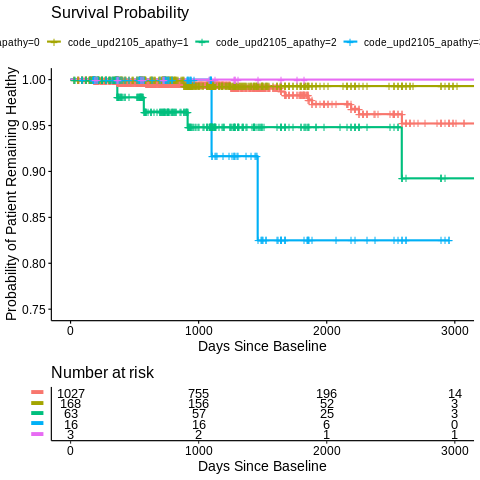

In [ ]:
%%R
g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, living_status_at_censoring == 1) ~ code_upd2105_apathy, data = PPc), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    ylim = c(.75,1),
    title = "Survival Probability ", 
    legend.title = "",
    risk.table.y.text = F,
    risk.table = TRUE)

print(g)

In [ ]:
!pip install -q tableone

In [ ]:
import tableone as t1
PP.loc[:,"cohort_phenotype"] = PP.cohort + "_" + PP.Phenotype
t1.TableOne(PP.drop_duplicates(subset = "participant_id",keep="last"),
            columns=["sex","age_at_baseline","code_upd2105_apathy","living_status_at_censoring"], groupby = ["Phenotype"])
  

Grouped by Phenotype                                       
                                                            Missing      Overall      Control           PD
n                                                                           2056          462         1594
sex, n (%)                        Female                          0   819 (39.8)   215 (46.5)   604 (37.9)
                                  Male                               1234 (60.0)   247 (53.5)   987 (61.9)
                                  Not Reported                           3 (0.1)                   3 (0.2)
age_at_baseline, mean (SD)                                        0   63.3 (9.8)  62.8 (11.2)   63.5 (9.4)
code_upd2105_apathy, n (%)        0.0                           533  1213 (79.6)   335 (93.3)   878 (75.4)
                                  1.0                                 192 (12.6)     21 (5.8)   171 (14.7)
                                  2.0                                   84 (5.5)      2 (0.6)     82 (7.0)
                                  3.0                                   29 (1.9)      1 (0.3)     28 (2.4)
                                  4.0                                    5 (0.3)                   5 (0.4)
living_status_at_censoring, n (%) 0.0                             0  2017 (98.1)   453 (98.1)  1564 (98.1)
                                  1.0                                   39 (1.9)      9 (1.9)     30 (1.9)

In [ ]:
PDBP[PDBP.Phenotype == "PD"]

,participant_id,visit_month,date_visit,date_baseline,age_at_baseline,sex,study_arm,Phenotype,living_status_at_censoring,age_at_living_status_censored,hoehn_and_yahr_stage,code_upd2102_hallucinations_and_psychosis,code_upd2103_depressed_mood,code_upd2105_apathy,mds_updrs_part_ii_summary_score,mds_updrs_part_iii_summary_score,moca_total_score,TEND,TSTART,cohort
10,NIHAJ851DKJYN,13.0,18565.0,18177.0,70.05,Male,224_PD,PD,0.0,71.133333,2.0,0.0,0.0,1.0,12.0,36.0,28.0,388.0,0.0,PDBP
16,NIHAM326MJZYU,18.0,18570.0,18040.0,55.09,Female,224_PD,PD,0.0,56.590000,2.0,0.0,1.0,2.0,11.0,41.0,26.0,530.0,0.0,PDBP
32,NIHBV849CEVGB,14.0,18604.0,18179.0,53.90,Female,224_PD,PD,0.0,55.066667,2.0,0.0,0.0,0.0,1.0,19.0,26.0,425.0,0.0,PDBP
36,NIHBY010MYFJQ,13.0,18597.0,18205.0,69.15,Male,224_PD,PD,0.0,70.233333,3.0,1.0,0.0,0.0,8.0,40.0,19.0,392.0,0.0,PDBP
38,NIHBY175BNPLJ,6.0,NaN,18274.0,53.98,Male,233_PD,PD,0.0,54.980000,2.0,2.0,2.0,0.0,8.0,19.0,NaN,180.0,0.0,PDBP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11085,PDZZ298XEH,13.0,16218.0,15819.0,77.07,Female,206_PD,PD,0.0,77.070000,2.0,0.0,0.0,1.0,7.0,15.0,20.0,399.0,182.0,PDBP
11086,PDZZ298XEH,23.0,16512.0,15819.0,77.07,Female,206_PD,PD,0.0,77.070000,2.0,0.0,4.0,1.0,29.0,14.0,19.0,693.0,399.0,PDBP
11087,PDZZ298XEH,32.0,16770.0,15819.0,77.07,Female,206_PD,PD,0.0,77.070000,2.0,0.0,0.0,0.0,25.0,20.0,NaN,951.0,693.0,PDBP
11088,PDZZ298XEH,40.0,17009.0,15819.0,77.07,Female,206_PD,PD,0.0,77.070000,2.0,0.0,0.0,0.0,13.0,15.0,20.0,1190.0,951.0,PDBP


## Fox Insight

In [ ]:
import pandas as pd 
import numpy as np

FSI = pd.read_csv("/content/gdrive/MyDrive/FoxInsight/raw_data/Financial_and_Social_Impact_of_Parkinsons_Disease.csv")

FSI = FSI.loc[:,["fox_insight_id","days_elapsed","schedule_of_activities","age","FinSocDiagApathy"]].dropna().reset_index(drop=True)

PDP = pd.read_csv("/content/gdrive/MyDrive/FoxInsight/raw_data/PDPROP.csv")
PDP = PDP.loc[:,PDP.columns.str.contains("fox|sched|elap|apath",case=False)]

AP = FSI.merge(PDP.drop("days_elapsed", axis=1), on = ["fox_insight_id","schedule_of_activities"], how = "outer")

AP = AP.join(pd.DataFrame(AP.iloc[:,4:].max(axis=1), columns = ["APAT"]))

DD = pd.read_csv("/content/gdrive/MyDrive/FoxInsight/_der_death.csv", usecols = ["fox_insight_id","LIV_AGE","PASSED"])

AP = AP.merge(DD, on = "fox_insight_id", how = "left").loc[:,["fox_insight_id","days_elapsed","schedule_of_activities","age","LIV_AGE","APAT","PASSED"]]

FAT = pd.read_csv("/content/gdrive/MyDrive/FoxInsight/raw_data/Understanding_Fatigue_in_Parkinsons_Patients.csv")

FAT = FAT.join(pd.Series((FAT.loc[:,FAT.columns.str.contains("Week")]-1).sum(axis=1) ,name = "AP_TOT")).loc[:,["fox_insight_id","schedule_of_activities","AP_TOT"]]

AP = AP.merge(FAT, on= ["fox_insight_id","schedule_of_activities"], how = "left").replace({"REG":0})
AP.loc[:,"schedule_of_activities"] = AP.schedule_of_activities.astype(float)
AP = AP.sort_values(["fox_insight_id","schedule_of_activities"]).reset_index(drop=True)

AP.update(AP.groupby("fox_insight_id").fillna(method='bfill'))

AP.loc[:,"TEND"] = (AP.schedule_of_activities * 30)
AP.loc[:,"IS_APAT"] = [1 if i > 14 else 0 if pd.notna(i) else np.nan for i in AP.AP_TOT]
AP.loc[:,"APAT"] = AP.APAT.fillna(AP.IS_APAT).fillna(0)
AP.loc[:,"PASSED"] = AP.PASSED.fillna(0)

AP = AP.loc[:,["fox_insight_id","TEND","APAT","PASSED"]].dropna()

AP.loc[:,"TSTART"] = AP.groupby("fox_insight_id").TEND.shift()

AP.to_csv("fox_apathy.csv", index = False)
AP

,fox_insight_id,TEND,APAT,PASSED,TSTART
0,FOX_000076,0.0,0.0,0.0,NaN
1,FOX_000087,0.0,1.0,0.0,NaN
2,FOX_000126,0.0,1.0,0.0,NaN
3,FOX_000126,420.0,1.0,0.0,0.0
4,FOX_000174,0.0,0.0,0.0,NaN
...,...,...,...,...,...
24398,FOX_999949,0.0,0.0,0.0,NaN
24399,FOX_999968,180.0,1.0,0.0,NaN
24400,FOX_999968,510.0,1.0,0.0,180.0
24401,FOX_999971,0.0,0.0,0.0,NaN


In [ ]:
FS

NameError: ignored

In [ ]:
FAD = pd.read_csv("/content/gdrive/MyDrive/FoxInsight/fox_apathy_data.csv")
FAD = FAD[ ['participant_id'] + [ col for col in FAD.columns if col != 'participant_id' ] ].drop("Unnamed: 0",axis=1).replace({"No":0,"Yes":1})
                                                                                                                               
FAD = FAD.loc[:,FAD.columns.str.contains("parti|visit_month|age_at_base|living")]

FAD

/usr/local/lib/python3.7/dist-packages/IPython/core/interactiveshell.py:2718: DtypeWarning: Columns (12,19,20,24) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


,participant_id,visit_month,age_at_baseline,living_status_at_censoring,age_at_living_status_censored
0,FOX_000087,0.0,63.3,NaN,NaN
1,FOX_000087,2.0,63.3,NaN,NaN
2,FOX_000087,5.0,63.3,NaN,NaN
3,FOX_000087,6.0,63.3,NaN,NaN
4,FOX_000087,9.0,63.3,NaN,NaN
...,...,...,...,...,...
16943,FOX_999971,16.0,67.6,NaN,NaN
16944,FOX_999971,18.0,67.6,NaN,NaN
16945,FOX_999971,21.0,67.6,NaN,NaN
16946,FOX_999971,22.0,67.6,NaN,NaN


In [ ]:
%%R
##Loads libraries required for analysis 
pack <- "/content/gdrive/My Drive/R/packages"

library(data.table, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(dplyr, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(lubridate, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library("ggpubr", lib.loc = pack)
library("ggplot2", lib.loc = pack)
library("ggpubr", lib.loc = pack)
library("survival", lib.loc = pack)
library("survminer", lib.loc = pack)
library(tidyr, lib.loc = pack)

FXA <- fread("fox_apathy.csv")
FXA

          V1 fox_insight_id TEND APAT PASSED
    1:     0     FOX_000076    0    0      0
    2:     1     FOX_000087    0    1      0
    3:     2     FOX_000126    0    1      0
    4:     3     FOX_000126  420    1      0
    5:     4     FOX_000174    0    0      0
   ---                                      
24096: 24398     FOX_999949    0    0      0
24097: 24399     FOX_999968  180    1      0
24098: 24400     FOX_999968  510    1      0
24099: 24401     FOX_999971    0    0      0
24100: 24402     FOX_999976    0    0      0


## PPMI

,participant_id,visit_month,date_visit,date_baseline,age_at_baseline,sex,living_status_at_censoring,age_at_living_status_censored,code_upd2105_apathy,gds15_total_score,TEND,TSTART
5,3000,13.0,15400.0,15006.0,70.083504,Female,0.0,79.16,0.0,1.0,394.0,0.0
7,3000,24.0,15737.0,15006.0,70.083504,Female,0.0,79.16,0.0,2.0,731.0,394.0
9,3000,37.0,16130.0,15006.0,70.083504,Female,0.0,79.16,0.0,2.0,1124.0,731.0
11,3000,49.0,16495.0,15006.0,70.083504,Female,0.0,79.16,0.0,1.0,1489.0,1124.0
13,3000,62.0,16892.0,15006.0,70.083504,Female,0.0,79.16,0.0,1.0,1886.0,1489.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16699,92834,9.0,16740.0,16467.0,67.085558,Male,0.0,72.16,0.0,2.0,273.0,-123.0
16701,92834,16.0,16953.0,16467.0,67.085558,Male,0.0,72.16,0.0,2.0,486.0,273.0
16705,92834,35.0,17532.0,16467.0,67.085558,Male,0.0,72.16,0.0,3.0,1065.0,486.0
16707,92834,49.0,17956.0,16467.0,67.085558,Male,0.0,72.16,0.0,3.0,1489.0,1065.0


In [ ]:
%%R
##Loads libraries required for analysis 
pack <- "/content/gdrive/My Drive/R/packages"

library(data.table, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(dplyr, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(lubridate, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library("ggpubr", lib.loc = pack)
library("ggplot2", lib.loc = pack)
library("ggpubr", lib.loc = pack)
library("survival", lib.loc = pack)
library("survminer", lib.loc = pack)
library(tidyr, lib.loc = pack)

PPMIc = fread("PPMI_cox.csv")

PPMI_cox <- coxph(formula = Surv(visit_month, living_status_at_censoring == 1) ~ I(code_upd2105_apathy > 1) + age_at_baseline + sex, data = PPMIc)

print(summary(PPMI_cox))

R[write to console]: 
Attaching package: ‘lubridate’


R[write to console]: The following objects are masked from ‘package:data.table’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


R[write to console]: The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




Call:
coxph(formula = Surv(visit_month, living_status_at_censoring == 
    1) ~ I(code_upd2105_apathy > 1) + age_at_baseline + sex, 
    data = PPMIc)

  n= 6877, number of events= 46 

                                  coef exp(coef) se(coef)     z Pr(>|z|)    
I(code_upd2105_apathy > 1)TRUE 0.83376   2.30196  0.39020 2.137  0.03262 *  
age_at_baseline                0.05769   1.05939  0.01715 3.363  0.00077 ***
sexMale                        0.63272   1.88273  0.35999 1.758  0.07882 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                               exp(coef) exp(-coef) lower .95 upper .95
I(code_upd2105_apathy > 1)TRUE     2.302     0.4344    1.0714     4.946
age_at_baseline                    1.059     0.9439    1.0244     1.096
sexMale                            1.883     0.5311    0.9297     3.813

Concordance= 0.685  (se = 0.041 )
Likelihood ratio test= 22.01  on 3 df,   p=6e-05
Wald test            = 21.4  on 3 df,   p=9e-05
Score (logrank) te

In [ ]:
%%R
##Loads libraries required for analysis 
pack <- "/content/gdrive/My Drive/R/packages"

library(data.table, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(dplyr, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(lubridate, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library("ggpubr", lib.loc = pack)
library("ggplot2", lib.loc = pack)
library("ggpubr", lib.loc = pack)
library("survival", lib.loc = pack)
library("survminer", lib.loc = pack)
library(tidyr, lib.loc = pack)

#DEMO contains diagnosis and gender variables
DEMO <- fread("/content/gdrive/My Drive/R/data/Screening___Demographics.csv",
              select = c("PATNO","APPRDX","CURRENT_APPRDX","GENDER")) %>%
        filter(PATNO < 4140) %>%
        arrange(PATNO) %>%
        mutate(APPRDX = if_else(APPRDX == CURRENT_APPRDX, APPRDX, CURRENT_APPRDX),
               CURRENT_APPRDX = NULL)     

##OCdat contains various demographic variables
OCdat <- fread("/content/gdrive/My Drive/R/data/OriginalCohortCleanedData.csv", 
               select = c("PATNO", "EVENT_ID", "race", "HISPLAT", "gen", "EDUCYRS", "age","duration", "ageonset",
                          "agediag")) %>%
               mutate(gen = gen - 1) %>%
               filter(EVENT_ID == "BL") %>%
               select(-"EVENT_ID")

modes <- function(x) {
  ux <- unique(x)
  tab <- tabulate(match(x, ux))
  ux[tab == max(tab)]
}

###A single race column is produced that includes hispanics, then added to GDS
OCdat <- mutate(OCdat, race = case_when(race == 1 & HISPLAT == 2 ~ "White", 
                                        race == 2 & HISPLAT == 2 ~ "Black", 
                                        race == 3 & HISPLAT == 2 ~ "Asian", 
                                        race == 4 & HISPLAT == 2 ~ "Other", 
                                        HISPLAT == 1 ~ "Hispanic"),
                HISPLAT = NULL)

OCrace <- aggregate(race ~ PATNO, OCdat, modes)
OCrace$race <- factor(OCrace$race, levels = c("White","Black",
                                              "Asian","Hispanic","Other"))
GDSOC <- left_join(DEMO, OCrace, by = "PATNO")

GDSOC <- left_join(DEMO, OCdat, by = c("PATNO"))

#UPDRS1 contains screening values for hallucinations and depression from MDS-UPDRS
UPDRS1 <- fread("/content/gdrive/My Drive/R/data/UPDRS1.csv") %>%
          filter(PATNO < 4140) %>%
          select(PATNO, EVENT_ID, INFODT, NP1HALL, NP1DPRS, NP1APAT) %>%
          mutate(INFODT = parse_date_time(INFODT, "mY")) %>%
          arrange(PATNO, INFODT)
names(UPDRS1)[c(3,4,5)] <- c("ENTRY_DATE","HALL","SUBDEP")

#Select issues with entry date are handled 
UPDRS1[PATNO == 4019 & EVENT_ID == "V01"]$ENTRY_DATE <- (UPDRS1[PATNO == 4019 & EVENT_ID == "V01"]$ENTRY_DATE + months(4))
UPDRS1[PATNO == 3056 & EVENT_ID == "ST"]$ENTRY_DATE <- (UPDRS1[PATNO == 3056 & EVENT_ID == "ST"]$ENTRY_DATE + months(3))
UPDRS1[PATNO == 3279 & EVENT_ID == "ST"]$ENTRY_DATE <- (UPDRS1[PATNO == 3279 & EVENT_ID == "ST"]$ENTRY_DATE + months(3))
UPDRS1[PATNO == 3604 & EVENT_ID == "V04"]$ENTRY_DATE <- (UPDRS1[PATNO == 3604 & EVENT_ID == "V04"]$ENTRY_DATE + months(3))
UPDRS1[PATNO == 4096 & EVENT_ID == "ST"]$ENTRY_DATE <- (UPDRS1[PATNO == 4096 & EVENT_ID == "ST"]$ENTRY_DATE + months(3))

#CNST contains screening values for constipation from UPDRS
CNST <- fread("/content/gdrive/My Drive/R/data/UPDRS1P.csv") %>%
        select(c("PATNO","EVENT_ID","NP1CNST")) %>%
        rename(CNST = NP1CNST)

UPDRS1 <- left_join(UPDRS1, CNST, by = c("PATNO", "EVENT_ID"))    
GDSOC <- left_join(GDSOC, UPDRS1, by = "PATNO")
GDSOC <- GDSOC[,c(1,11,12,2:10,13:15)]#rearranges columns for readability 


#UPDRS2 contains the total score for MDS-UPDRS Part II
UPDRS2 <- fread("/content/gdrive/My Drive/R/data/UPDRS2.csv")
UPDRS2 <- mutate(UPDRS2, UP2TOT = rowSums(UPDRS2[,7:20]), .after = NP2FREZ) %>%
          select(c("PATNO","EVENT_ID","UP2TOT"))

#Fixes issue where one patients first UPDRS was not at baseline
UPDRS2[PATNO == 4070 & EVENT_ID == "SC"]$UP2TOT <- 3
UPDRS2[PATNO == 4070 & EVENT_ID == "SC"]$EVENT_ID <- "BL"

#Rather than sorting through medication data, the question regarding PD medication use is pulled from UPDRS3
UPDRS3 <- fread("/content/gdrive/My Drive/R/data/MDS_UPDRS_Part_III.csv")
UPDRS3 <- mutate(UPDRS3, UP3TOT = rowSums(UPDRS3[,12:44]), .after = NP3RTCON) %>%
          select(c("PATNO","EVENT_ID","PD_MED_USE","UP3TOT")) %>%
          arrange(PATNO,EVENT_ID)

GDSOC <- left_join(GDSOC, UPDRS2, by = c("PATNO", "EVENT_ID"))
GDSOC <- left_join(GDSOC, UPDRS3, by = c("PATNO", "EVENT_ID"))

#Entries without EVENT_ID are removed, dataset is then arranged by patient id and entry date
GDSOC <- filter(GDSOC,!is.na(EVENT_ID)) %>%
         arrange(PATNO, ENTRY_DATE)

#GDS total column and depression severity columns are added
GDS <- fread("/content/gdrive/My Drive/R/data/Geriatric_Depression_Scale__Short_.csv") %>%
        select(c("PATNO", "EVENT_ID", starts_with("GDS")))
GDS <- mutate(GDS, TOT = rowSums(GDS[,3:17])) %>%
        select(-starts_with("GDS")) %>%
        rename(GDSTOT = TOT) %>%
        filter(!is.na(GDSTOT)) %>%
        mutate(IS_DEP = if_else(GDSTOT <= 5, 0, 1))
        
GDSOC <- left_join(GDSOC, GDS, by = c("PATNO","EVENT_ID"))

#MOCA scores are added
MOCA <- fread("/content/gdrive/My Drive/R/data/Montreal_Cognitive_Assessment__MoCA_.csv") %>%
        select("PATNO","EVENT_ID","MCATOT") %>%
        filter(PATNO < 4200) %>%
        mutate(EVENT_ID = if_else(EVENT_ID == "SC", "BL",EVENT_ID))

GDSOC <- left_join(GDSOC, MOCA, by = c("PATNO", "EVENT_ID"))

#Daytime Sleepiness Measures are added
ESS    <- fread("/content/gdrive/My Drive/R/data/Epworth_Sleepiness_Scale.csv")
ESS    <- mutate(ESS, ESSTOT = rowSums(ESS[,8:15])) %>%
          mutate(IS_SLEEPY = if_else(ESSTOT > 10, 1, 0)) %>%
          filter(PATNO < 4140) %>%
          select(PATNO, EVENT_ID, ESSTOT, IS_SLEEPY)

GDSOC <- left_join(GDSOC, ESS, by = c("PATNO", "EVENT_ID"))

#REM sleep behavior disorder measures are added
REM <- fread("/content/gdrive/My Drive/R/data/REM_Sleep_Disorder_Questionnaire.csv") %>%
       select(-c("REC_ID", "F_STATUS", "PAG_NAME","INFODT","LAST_UPDATE","QUERY",
                 "SITE_APRV", "CNSOTH", "CNSOTHCM","ORIG_ENTRY"))
REM <- mutate(REM, REM_TOT = rowSums(REM[,3:15])) %>%
       mutate(RBD = if_else(REM_TOT > 5, 1, 0)) 
REM <- REM[,-(3:24)]

GDSOC <- left_join(GDSOC, REM, by = c("PATNO", "EVENT_ID"))

#Hyposmia measures are added
UPSIT <- fread("/content/gdrive/My Drive/R/data/UPSIT.csv") %>%
         select(contains(c("PATNO","EVENT","UPSIT","NORM")))
UPSIT <- UPSIT %>%
         mutate(UPSIT = rowSums(UPSIT[,3:6])) %>%
         left_join(OCdat[,c("PATNO","gen","age")], by = "PATNO") %>%
         mutate(FEMALE = gen) %>%
         mutate(HYPOS = case_when((FEMALE==1) & (age<25) & (UPSIT<=35) ~ 1,
                                  (FEMALE==1) & (age<50) & (UPSIT<=34) ~ 1,
                                  (FEMALE==1) & (age<60) & (UPSIT<=32) ~ 1,
                                  (FEMALE==1) & (age<65) & (UPSIT<=31) ~ 1,
                                  (FEMALE==1) & (age<70) & (UPSIT<=26) ~ 1,
                                  (FEMALE==1) & (age<75) & (UPSIT<=22) ~ 1,
                                  (FEMALE==1) & (age<80) & (UPSIT<=17) ~ 1,
                                  (FEMALE==1) & (age>=80) & (UPSIT<=15) ~ 1,
                                  (FEMALE==0) & (age<40) & (UPSIT<=33) ~ 1,
                                  (FEMALE==0) & (age<50) & (UPSIT<=32) ~ 1,
                                  (FEMALE==0) & (age<55) & (UPSIT<=29) ~ 1,
                                  (FEMALE==0) & (age<65) & (UPSIT<=26) ~ 1,
                                  (FEMALE==0) & (age<70) & (UPSIT<=22) ~ 1,
                                  (FEMALE==0) & (age<75) & (UPSIT<=19) ~ 1,
                                  (FEMALE==0) & (age<80) & (UPSIT<=18) ~ 1,
                                  (FEMALE==0) & (age<85) & (UPSIT<=12) ~ 1,
                                  (FEMALE==0) & (age>=85) & (UPSIT<=10) ~ 1,
                                  !(is.na(UPSIT)) ~ 0)) %>% #Hyposmia is normalized
        mutate(HYPOS_S = if_else(UPSIT <= 21, 1, 0)) %>%
        select(contains(c("PATNO","EVENT_ID","HYPOS","HYPOS_S")))

GDSOC <- left_join(GDSOC, UPSIT, by = c("PATNO", "EVENT_ID"))

#Data for antidepressant use is added
DEPmed <- fread("/content/gdrive/My Drive/R/data/Concomitant_Medications.csv")
depmeds <- fread("/content/gdrive/My Drive/R/data/der_depmeds.csv")##See additional python code
DEPmed <- filter(DEPmed, WHODRUG %in% depmeds$V2) %>%
          select(c("PATNO", "WHODRUG","STARTDT", "STOPDT", "ONGOING",
                   "ORIG_ENTRY")) %>%
          mutate(ORIG_ENTRY = parse_date_time(ORIG_ENTRY, "mY"),
                 STARTDT = parse_date_time(STARTDT, "mY"),
                 STOPDT = parse_date_time(STOPDT, "mY")) %>%
          arrange(PATNO, ORIG_ENTRY) %>% 
          filter(PATNO < 4140) %>%
          mutate(ONGOING = if_else(is.na(STOPDT), 1, as.double(ONGOING)))

#Data for death is added
death <- fread("/content/gdrive/My Drive/R/data/death.csv")
names(death)[2] <- "age_death"

GDSOC <- left_join(GDSOC, death, by = c("PATNO"))

#Removes nonessential visits and duplicates
GDSOC <- filter(GDSOC, EVENT_ID != "SC")
GDSOC <- filter(GDSOC, EVENT_ID != "RS1")
GDSOC <- GDSOC[!duplicated(GDSOC)]
          
##Data is subset based on patient id, then cleaned
unique_PATNO <- unique(GDSOC$PATNO)
num_unique <- length(unique_PATNO)
GDStemp <- data.frame()

for (i in 1:num_unique) {
  PATNO_subset <- filter(GDSOC, PATNO == unique_PATNO[i])
  len <- nrow(PATNO_subset)

  #Patients with only one entry are skipped
  if(len == 1) { 
      next
  }

  #Duplicated entry dates are offset by 3 months
  if (!(length(unique(PATNO_subset$ENTRY_DATE)) == len)) {
      dups <- duplicated(PATNO_subset$ENTRY_DATE)
      for (w in 1:nrow(PATNO_subset[dups])) {
          PATNO_subset[dups]$ENTRY_DATE[w] <- PATNO_subset[dups]$ENTRY_DATE[w] - months(3)

      }
  }
  
  #Important baseline and time-related variables are added
  BL <- filter(PATNO_subset, EVENT_ID == "BL")
  PATNO_subset <- mutate(PATNO_subset, age = round(age + time_length(ENTRY_DATE - BL$ENTRY_DATE, "years"),2))
  PATNO_subset <- mutate(PATNO_subset, durdx = age - agediag)
  BL <- filter(PATNO_subset, EVENT_ID == "BL")
  PATNO_subset <- mutate(PATNO_subset, YRS_BL = round(interval(BL$ENTRY_DATE,ENTRY_DATE) / years(1),2), 
       .after = "EVENT_ID")
  PATNO_subset <- mutate(PATNO_subset, BL_age = BL$age, BL_durdx = BL$durdx,
                         BL_RBD = BL$RBD, BL_SLEEP = BL$IS_SLEEPY,
                         BL_HALL = BL$HALL, BL_UP2 = BL$UP2TOT, 
                         BL_UP3 = BL$UP3TOT,BL_HYP = BL$HYPOS)


  ##Adds depression medication
  if (unique_PATNO[i] %in% DEPmed$PATNO) {
    DPM <- filter(DEPmed, PATNO == unique_PATNO[i])
    if (nrow(DPM) > 1) {
      if (sum(is.na(DPM$STOPDT)) > 0) {
        ##Indicates at least one medication has not been stopped
        DPM <- filter(DPM, is.na(STOPDT))
        med_start <- min(DPM$STARTDT)
        PATNO_subset <- mutate(PATNO_subset, DEP_MED = if_else(ENTRY_DATE > med_start, 1, 0))
      } else { 
        PATNO_subset <- mutate(PATNO_subset, DEP_MED = 0)
        for (j in 1:nrow(DPM)) {
          int <- interval(DPM$STARTDT[j], DPM$STOPDT[j])
          PATNO_subset <- mutate(PATNO_subset, DEP_MED = if_else(ENTRY_DATE %within% int, 1, DEP_MED))
        }
      }
    } else if (is.na(DPM$STOPDT)) {
      ##For when there is only one medication and it has has not been stopped
      DPM <- filter(DPM, is.na(STOPDT))
      med_start <- min(DPM$STARTDT)
      PATNO_subset <- mutate(PATNO_subset, DEP_MED = if_else(ENTRY_DATE > med_start, 1, 0))
    } else {
      int <- interval(DPM$STARTDT[1], DPM$STOPDT[1])
      PATNO_subset <- mutate(PATNO_subset, DEP_MED = if_else(ENTRY_DATE %within% int, 1, 0))
    }
  } else {
    PATNO_subset <- mutate(PATNO_subset, DEP_MED = 0)
  }
  
  #MoCA values are interpolated
  PATNO_subset <- fill(PATNO_subset, MCATOT, .direction = "downup")

  PATNO_subset <- mutate(PATNO_subset, IS_DEAD = 0)

  if (1 %in% PATNO_subset$death) {
      PATNO_subset$IS_DEAD[len] <- 1
  }

  PATNO_subset <- mutate(PATNO_subset, TSTART = 0, .before = "YRS_BL")
  for (k in 2:len) {
   PATNO_subset$TSTART[k] <- PATNO_subset$YRS_BL[k-1]
  }
  PATNO_subset <- rename(TEND = YRS_BL, PATNO_subset)

  ##rejoins subset to new data set
  GDStemp <- rbind(GDStemp, PATNO_subset)
}

GDSOC <- rename(PD_STATUS = APPRDX, GDStemp)

##GDSOC is subsetted to remove SWEDD and HC patients. 
GDSPD <- filter(GDSOC, PD_STATUS == 1)

##GDSOC is subsetted to remove SWEDD and PD patients
GDSHC <- filter(GDSOC, PD_STATUS == 2)

##GDSPD is subsetted to include only baseline visits
GO.BL <- as_tibble(filter(GDSOC, EVENT_ID == "BL"))

GDSOC

R[write to console]: data.table 1.13.0 using 1 threads (see ?getDTthreads).  Latest news: r-datatable.com

R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:data.table’:

    between, first, last


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


R[write to console]: 
Attaching package: ‘lubridate’


R[write to console]: The following objects are masked from ‘package:data.table’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


R[write to console]: The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


R[write to console]: Loading required package: ggplot2



      PATNO EVENT_ID TSTART TEND ENTRY_DATE PD_STATUS GENDER  race gen EDUCYRS
   1:  3000       BL   0.00 0.00 2011-02-01         2      1 White   1      18
   2:  3000      V04   0.00 1.08 2012-03-01         2      1 White   1      18
   3:  3000      V06   1.08 2.00 2013-02-01         2      1 White   1      18
   4:  3000      V08   2.00 3.08 2014-03-01         2      1 White   1      18
   5:  3000      V10   3.08 4.08 2015-03-01         2      1 White   1      18
  ---                                                                         
8352:  4136      V07   2.00 2.58 2015-10-01         1      2 White   0      13
8353:  4136      V09   2.58 3.50 2016-09-01         1      2 White   0      13
8354:  4139       BL   0.00 0.00 2013-04-01         2      2 White   0      15
8355:  4139      V04   0.00 0.92 2014-03-01         2      2 White   0      15
8356:  4139      V06   0.92 2.00 2015-04-01         2      2 White   0      15
        age duration ageonset  agediag HALL SUBDEP N

In [ ]:
%%R
GDSPD <- mutate(GDSPD, APAT = if_else(NP1APAT > 1, 1, 0))
APAT_cox <- coxph(formula = Surv(TSTART, TEND, IS_DEAD == 1) ~ IS_DEP, data = GDSPD)

print(summary(APAT_cox))

Call:
coxph(formula = Surv(TSTART, TEND, IS_DEAD == 1) ~ IS_DEP, data = GDSPD)

  n= 2876, number of events= 10 
   (3841 observations deleted due to missingness)

           coef exp(coef) se(coef)      z Pr(>|z|)
IS_DEP -0.07561   0.92718  0.64801 -0.117    0.907

       exp(coef) exp(-coef) lower .95 upper .95
IS_DEP    0.9272      1.079    0.2604     3.302

Concordance= 0.522  (se = 0.08 )
Likelihood ratio test= 0.01  on 1 df,   p=0.9
Wald test            = 0.01  on 1 df,   p=0.9
Score (logrank) test = 0.01  on 1 df,   p=0.9



In [ ]:
%%R
filter(GDSOC, death == 1)

     PATNO EVENT_ID TSTART TEND ENTRY_DATE PD_STATUS GENDER  race gen EDUCYRS
  1:  3059       BL   0.00 0.00 2011-02-01         1      2 White   0      19
  2:  3059      V01   0.00 0.24 2011-05-01         1      2 White   0      19
  3:  3059      V02   0.24 0.58 2011-09-01         1      2 White   0      19
  4:  3059      V03   0.58 0.83 2011-12-01         1      2 White   0      19
  5:  3059      V04   0.83 1.00 2012-02-01         1      2 White   0      19
 ---                                                                         
303:  4124      V08   2.42 3.08 2016-05-01         1      2 White   0      14
304:  4124      V08   3.08 2.84 2016-02-01         1      2 White   0      14
305:  4124      V09   2.84 3.42 2016-09-01         1      2 White   0      14
306:  4124      V13   3.42 6.00 2019-04-01         1      2 White   0      14
307:  4124      V13   6.00 5.75 2019-01-01         1      2 White   0      14
       age  duration ageonset  agediag HALL SUBDEP NP1APAT UP2TO

In [ ]:




GDSOC_DA7 <- filter(GDSOC, !is.na(IS_DEP))

unique_PATNO <- unique(GDSOC_DA7$PATNO)
num_unique <- length(unique_PATNO)
GDSOC_DA9 <- data.frame()
cox_dat <- data.frame()
cox_subset <- data.frame()

for (i in 1:num_unique) {
  PATNO_subset <- filter(GDSOC_DA7, PATNO == unique_PATNO[i])
  len <- nrow(PATNO_subset)

  if (len == 1) {
      next
  }

  #Depression events that were not sustained for two visits are removed
  for (j in 1:(len-1)) {
    if (PATNO_subset$IS_DEP[j] == 1 & PATNO_subset$IS_DEP[j+1] == 0) {
        PATNO_subset$IS_DEP[j] <- 0
    }
  }
  
  #Data is converted to cox model friendly format
  PATNO_subset <- mutate(PATNO_subset, TSTART = 0, .before = "YRS_BL")
  for (k in 2:len) {
   PATNO_subset$TSTART[k] <- PATNO_subset$YRS_BL[k-1]
  }
  PATNO_subset <- rename(TEND = YRS_BL, PATNO_subset)
  GDSOC_DA9 <- rbind(GDSOC_DA9, PATNO_subset)


  cox_subset <- PATNO_subset
  len <- nrow(cox_subset)
  first_ons <- 0

  if (len > 1) {
    for (j in 2:len) {
        if (cox_subset$IS_DEP[j] == 1) {
            cox_subset <- cox_subset[1:j]
            break
        }
    }
  }

cox_dat <- rbind(cox_dat, cox_subset)
} 

PPMI_fulldat <- cox_dat

DBL_PTs <- filter(cox_dat, IS_DEP == 1 & EVENT_ID == "BL")$PATNO
cox_dat_PD <- filter(cox_dat, PD_STATUS == 1 & EVENT_ID != "BL")
PPMI_coxdat <- filter(cox_dat_PD, !(PATNO %in% DBL_PTs))

summary(PPMI_coxdat)

     PATNO        EVENT_ID             TSTART           TEND      
 Min.   :3001   Length:2110        Min.   :0.000   Min.   :0.080  
 1st Qu.:3234   Class :character   1st Qu.:0.500   1st Qu.:1.000  
 Median :3472   Mode  :character   Median :2.000   Median :2.830  
 Mean   :3547                      Mean   :2.449   Mean   :3.094  
 3rd Qu.:3832                      3rd Qu.:4.000   3rd Qu.:4.830  
 Max.   :4135                      Max.   :9.080   Max.   :9.080  
                                                                  
   ENTRY_DATE                    PD_STATUS     GENDER          race          
 Min.   :2011-01-01 00:00:00   Min.   :1   Min.   :0.000   Length:2110       
 1st Qu.:2013-06-01 00:00:00   1st Qu.:1   1st Qu.:1.000   Class :character  
 Median :2015-01-01 00:00:00   Median :1   Median :2.000   Mode  :character  
 Mean   :2015-04-13 20:35:15   Mean   :1   Mean   :1.583                     
 3rd Qu.:2017-01-01 00:00:00   3rd Qu.:1   3rd Qu.:2.000                  

In [ ]:
%%R


UPDRS3

       PATNO EVENT_ID PD_MED_USE UP3TOT
    1:  3000       BL         NA      4
    2:  3000      V04         NA      1
    3:  3000      V06         NA      4
    4:  3000      V08         NA      2
    5:  3000      V10         NA     19
   ---                                 
15839: 92834      V08          0      0
15840: 92834      V09          0      1
15841: 92834      V10          0      0
15842: 92834      V11          0      1
15843: 92834      V12          0      1


### Logistic Regression

In [ ]:
%%R
PPMI_log <- filter(PPMI_fulldat, EVENT_ID == "BL" & PD_STATUS == 1) 

LM <- glm(formula = IS_DEP ~  I(EDUCYRS>15) + gen + age + durdx + BL_UP2 + BL_UP3 + BL_RBD + BL_SLEEP + BL_HYP + BL_CNST + BL_HALL +
             MCATOT + DEP_MED, family = "binomial", data = PPMI_log)
print(summary(LM))
print(exp(coef(LM)))
exp(confint(LM))


Call:
glm(formula = IS_DEP ~ I(EDUCYRS > 15) + gen + age + durdx + 
    BL_UP2 + BL_UP3 + BL_RBD + BL_SLEEP + BL_HYP + BL_CNST + 
    BL_HALL + MCATOT + DEP_MED, family = "binomial", data = PPMI_log)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-1.5160  -0.7217  -0.5776  -0.4066   2.2190  

Coefficients:
                    Estimate Std. Error z value Pr(>|z|)  
(Intercept)         -1.52223    1.92306  -0.792   0.4286  
I(EDUCYRS > 15)TRUE -0.34484    0.25413  -1.357   0.1748  
gen                 -0.27623    0.27243  -1.014   0.3106  
age                 -0.02374    0.01321  -1.798   0.0723 .
durdx                0.15137    0.22306   0.679   0.4974  
BL_UP2               0.06025    0.03345   1.801   0.0717 .
BL_UP3              -0.01726    0.01626  -1.062   0.2884  
BL_RBD               0.71042    0.28185   2.521   0.0117 *
BL_SLEEP             0.03132    0.44751   0.070   0.9442  
BL_HYP               0.26085    0.28766   0.907   0.3645  
BL_CNST             -

R[write to console]: Waiting for profiling to be done...



                         2.5 %    97.5 %
(Intercept)         0.00456223  8.834565
I(EDUCYRS > 15)TRUE 0.42968241  1.166282
gen                 0.43986347  1.283817
age                 0.95143687  1.002139
durdx               0.73881755  1.781810
BL_UP2              0.99445101  1.134309
BL_UP3              0.95142512  1.014209
BL_RBD              1.16622742  3.530813
BL_SLEEP            0.41080179  2.406316
BL_HYP              0.74597034  2.313756
BL_CNST             0.24345335  1.909824
BL_HALL             0.81583143 10.210323
MCATOT              0.94191670  1.181463
DEP_MED             0.61391578  2.999081


### GDSS Survival Analysis

In [ ]:
%%R
PPMI_cox <- coxph(formula = Surv(TSTART, TEND, IS_DEP == 1) ~ 
    I(EDUCYRS>15) + gen + BL_age + BL_durdx + BL_UP2 + BL_UP3 + BL_RBD + BL_HYP  + BL_CNST + MCATOT + DEP_MED, data = PPMI_coxdat)

print(summary(PPMI_cox))

Call:
coxph(formula = Surv(TSTART, TEND, IS_DEP == 1) ~ I(EDUCYRS > 
    15) + gen + BL_age + BL_durdx + BL_UP2 + BL_UP3 + BL_RBD + 
    BL_HYP + BL_CNST + MCATOT + DEP_MED, data = PPMI_coxdat)

  n= 1622, number of events= 187 
   (488 observations deleted due to missingness)

                          coef  exp(coef)   se(coef)      z Pr(>|z|)    
I(EDUCYRS > 15)TRUE -0.0006523  0.9993479  0.1555295 -0.004 0.996653    
gen                 -0.1176553  0.8890025  0.1655994 -0.710 0.477406    
BL_age               0.0005148  1.0005150  0.0092957  0.055 0.955832    
BL_durdx             0.0160030  1.0161318  0.1378940  0.116 0.907611    
BL_UP2               0.0655359  1.0677311  0.0198029  3.309 0.000935 ***
BL_UP3              -0.0038298  0.9961775  0.0097013 -0.395 0.693012    
BL_RBD              -0.0228809  0.9773789  0.1842104 -0.124 0.901148    
BL_HYP               0.3987842  1.4900120  0.1685024  2.367 0.017950 *  
BL_CNST              0.8856541  2.4245698  0.2683359  3.301 0.00

In [ ]:
%%R
ggcoxfunctional(Surv(TSTART, TEND, IS_DEP == 1) ~ MCATOT + log(MCATOT) + sqrt(MCATOT), data = PPMI_coxdat)

R[write to console]: Error in xy.coords(x, y, setLab = FALSE) : 'x' and 'y' lengths differ

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: arguments formula is deprecated; will be removed in the next version; please use fit instead. 

R[write to console]: 2: 
R[write to console]: In Surv(TSTART, TEND, IS_DEP == 1) :
R[write to console]: 
 
R[write to console]:  Stop time must be > start time, NA created

R[write to console]: 3: 
R[write to console]: In log(MCATOT) :
R[write to console]:  NaNs produced

R[write to console]: 4: 
R[write to console]: In Surv(TSTART, TEND, IS_DEP == 1) :
R[write to console]: 
 
R[write to console]:  Stop time must be > start time, NA created




Error in xy.coords(x, y, setLab = FALSE) : 'x' and 'y' lengths differ


RInterpreterError: ignored

### UPDRSd Sensitivity Analysis
This section of code reformats data to be based around depression events defined by UPDRS rather than GDS

In [ ]:
%%R
GDSOC <- mutate(GDSOC, SD2 = if_else(SUBDEP > 1, 1, 0))
GDSOC_SD2 <- filter(GDSOC, !is.na(SD2))

SD2_BL <- filter(GDSOC_SD2[!duplicated(GDSOC_SD2$PATNO)], SD2 == 0)$PATNO

SD2_dat <- filter(GDSOC_SD2, PATNO %in% SD2_BL)

SD2_PTs <- unique(SD2_dat$PATNO) 
SD2_PTs <- sort(SD2_PTs)

num_unique <- length(SD2_PTs)

SD2_cox <- data.frame()
PATNO_subset <- data.frame()

for (i in 1:num_unique) {
  PATNO_subset <- filter(SD2_dat, PATNO == SD2_PTs[i])
  len <- nrow(PATNO_subset)
  first_ons <- 0
  
  PATNO_subset <- mutate(PATNO_subset, TSTART = 0, .before = "YRS_BL")

  if (len == 1) {
      next 
  }

  for (k in 2:len) {
   PATNO_subset$TSTART[k] <- PATNO_subset$YRS_BL[k-1]
  }

  PATNO_subset <- rename(TEND = YRS_BL, PATNO_subset)
     

    for (j in 2:len) {
        if (is.na(PATNO_subset$SD2[j])){
            PATNO_subset$SD2[j] <- PATNO_subset$SD2[j-1]
        } else if (PATNO_subset$SD2[j] == 1 & first_ons == 0) {
            PATNO_subset <- PATNO_subset[1:j]
            first_ons <- j
            break
        }
     }
    
  
SD2_cox <- rbind(SD2_cox, PATNO_subset)
} 

SD2_cox <- filter(SD2_cox, EVENT_ID != "BL")

PPMI_sddat <- filter(SD2_cox, PD_STATUS == 1)

PPMI_sd <- coxph(Surv(TSTART, TEND, SD2) ~ I(EDUCYRS>15) + gen + BL_age + BL_durdx + BL_UP2 + BL_UP3 + BL_RBD + BL_HYP
                 + BL_CNST + MCATOT + DEP_MED, data = PPMI_sddat)

print(summary(PPMI_sd))

Call:
coxph(formula = Surv(TSTART, TEND, SD2) ~ I(EDUCYRS > 15) + gen + 
    BL_age + BL_durdx + BL_UP2 + BL_UP3 + BL_RBD + BL_HYP + BL_CNST + 
    MCATOT + DEP_MED, data = PPMI_sddat)

  n= 3946, number of events= 141 
   (837 observations deleted due to missingness)

                         coef exp(coef)  se(coef)      z Pr(>|z|)    
I(EDUCYRS > 15)TRUE -0.148565  0.861944  0.180661 -0.822   0.4109    
gen                  0.373943  1.453455  0.182275  2.052   0.0402 *  
BL_age               0.008788  1.008826  0.009782  0.898   0.3690    
BL_durdx            -0.174336  0.840014  0.165012 -1.057   0.2907    
BL_UP2               0.057511  1.059197  0.022878  2.514   0.0119 *  
BL_UP3              -0.014346  0.985757  0.011014 -1.302   0.1928    
BL_RBD               0.172732  1.188548  0.198056  0.872   0.3831    
BL_HYP               0.218268  1.243921  0.190780  1.144   0.2526    
BL_CNST              1.039054  2.826541  0.264432  3.929 8.52e-05 ***
MCATOT              -0.037059 

## PDBP

In [ ]:
PDBP[PDBP.participant_id == "NIHAA453JFRNE"]

,participant_id,visit_month,date_visit,date_baseline,age_at_baseline,study_arm,living_status_at_censoring,age_at_living_status_censored,code_upd2105_apathy,daysB
0,NIHAA453JFRNE,0.0,18278.0,18278.0,73.8,233_Other,0.0,NaN,0.0,0.0


,participant_id,visit_month,date_visit,date_baseline,age_at_baseline,sex,study_arm,living_status_at_censoring,age_at_living_status_censored,code_upd2105_apathy,TEND,TSTART,gds15_total_score
2,NIHAE744BKPKG,8.0,18445.0,18211.0,60.180000,Male,232_Other,0.0,NaN,0.0,234.0,0.0,NaN
3,NIHAE744BKPKG,12.0,NaN,18211.0,60.180000,Male,232_Other,0.0,NaN,0.0,360.0,234.0,NaN
8,NIHAH996FTXAP,16.0,18632.0,18144.0,69.800000,Female,224_Control,0.0,NaN,0.0,488.0,0.0,NaN
10,NIHAJ851DKJYN,13.0,18565.0,18177.0,70.000000,Male,224_PD,0.0,NaN,1.0,388.0,0.0,NaN
12,NIHAL261NEKWD,6.0,NaN,NaN,63.770000,Male,236_Other,0.0,NaN,0.0,180.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16699,92834,9.0,16740.0,16467.0,67.085558,Male,NaN,0.0,72.16,0.0,273.0,-123.0,2.0
16701,92834,16.0,16953.0,16467.0,67.085558,Male,NaN,0.0,72.16,0.0,486.0,273.0,2.0
16705,92834,35.0,17532.0,16467.0,67.085558,Male,NaN,0.0,72.16,0.0,1065.0,486.0,3.0
16707,92834,49.0,17956.0,16467.0,67.085558,Male,NaN,0.0,72.16,0.0,1489.0,1065.0,3.0


Call:
coxph(formula = Surv(visit_month, living_status_at_censoring == 
    1) ~ I(code_upd2105_apathy > 1) + age_at_baseline + sex, 
    data = PPMIc)

  n= 6877, number of events= 46 

                                  coef exp(coef) se(coef)     z Pr(>|z|)    
I(code_upd2105_apathy > 1)TRUE 0.83376   2.30196  0.39020 2.137  0.03262 *  
age_at_baseline                0.05769   1.05939  0.01715 3.363  0.00077 ***
sexMale                        0.63272   1.88273  0.35999 1.758  0.07882 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

                               exp(coef) exp(-coef) lower .95 upper .95
I(code_upd2105_apathy > 1)TRUE     2.302     0.4344    1.0714     4.946
age_at_baseline                    1.059     0.9439    1.0244     1.096
sexMale                            1.883     0.5311    0.9297     3.813

Concordance= 0.685  (se = 0.041 )
Likelihood ratio test= 22.01  on 3 df,   p=6e-05
Wald test            = 21.4  on 3 df,   p=9e-05
Score (logrank) te

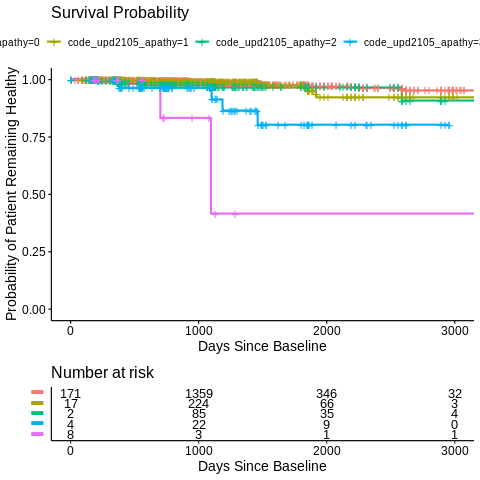

In [ ]:
%%R
##Loads libraries required for analysis 
pack <- "/content/gdrive/My Drive/R/packages"

library(data.table, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(dplyr, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(ggpubr, lib.loc=pack)
library("survival", lib.loc = pack)
library("survminer", lib.loc = pack)
library(tidyr, lib.loc = pack)

PDBPc = fread("PDBP_cox.csv")
PPc = fread("PP_cox.csv")

PPc = filter(PPc, sex != "Not Reported")

PDBP_cox <- coxph(formula = Surv(TSTART, TEND, living_status_at_censoring == 1) ~ code_upd2105_apathy + age_at_baseline + sex, data = PDBPc)


print(summary(PPMI_cox))
print(summary(PDBP_cox))

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, living_status_at_censoring == 1) ~ code_upd2105_apathy, data = PPc), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Survival Probability ", 
    legend.title = "",
    risk.table.y.text = F,
    risk.table = TRUE)

print(g)

In [ ]:
%%R
##Loads libraries required for analysis 
pack <- "/content/gdrive/My Drive/R/packages"

library(data.table, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(dplyr, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library(lubridate, lib.loc = pack, quietly = TRUE, verbose = FALSE)
library("ggpubr", lib.loc = pack)
library("ggplot2", lib.loc = pack)
library("ggpubr", lib.loc = pack)
library("survival", lib.loc = pack)
library("survminer", lib.loc = pack)
library(tidyr, lib.loc = pack)

##HDRS serves as the base for this dataset and the key for attaching new datasets
HDRS <- fread("/content/gdrive/My Drive/R/PDBPdata/HDRS.csv") %>%
        select(contains(c("Study ID","GUID", "TotScore", "VisitTyp"))) %>%
        distinct()

##This section makes aesthetic changes to make the dataset more readable
names(HDRS) <- c("STUDY","GUID", "HAMTOT", "EVENT_ID")


## UPDRS is a dataset describing items from the MDS Unified Parkinson's Disease Rating Scale and 
## contains important outcomes such as our second measure of depression (UPDRSd) and the ADL score
UPDRS <- fread("/content/gdrive/My Drive/R/PDBPdata/UPDRS.csv") %>%
        select(contains(c("Study","GUID","VisitTyp","VisitDate","Halluc","Drpss","Constip","PartIIScore","PartIIIScore","PrknsnMedInd")))

names(UPDRS) <- c("STUDY","GUID","EVENT_ID", "VISIT_DATE","HALL","SUB_DEP","CNST","UP2TOT","UP3TOT","PD_MED_USE")

UPDRS <- UPDRS %>%
         mutate(HALL = if_else(HALL == 0, 0, 1))

raw_dat <- full_join(HDRS,UPDRS, by = c("STUDY", "GUID", "EVENT_ID")) %>%
           arrange(GUID, STUDY, VISIT_DATE)%>%
           filter(!is.na(HAMTOT) | !is.na(SUB_DEP))

##Missing visit dates were added manually based on event id 
raw_dat[GUID %in% c("PDTA563EX1","PDPP716EP5","PDAW779GWK","PDTD077VRD") & is.na(VISIT_DATE)]$VISIT_DATE <- 
as_datetime(c("2015-07-08 09:30:00","2018-04-29 09:30:00","2013-09-07 00:00:00","2017-10-03 11:00:00"))
raw_dat[GUID %in% c("PDHG251ALZ","PDMW095JLA") & is.na(VISIT_DATE)]<- 
as_datetime(c("2018-10-18","2018-10-23")) 

VDNA <- filter(raw_dat, is.na(VISIT_DATE))$GUID
vtemp <- raw_dat[GUID %in% VDNA] 
vtemp <- fill(vtemp, VISIT_DATE)
vtemp[duplicated(vtemp$VISIT_DATE)]$VISIT_DATE <- 
vtemp[duplicated(vtemp$VISIT_DATE)]$VISIT_DATE + days(183)
raw_dat[GUID %in% VDNA] <- vtemp

raw_dat <- raw_dat %>%
           mutate(YRS_BL= case_when(EVENT_ID == "Baseline" ~ 0,
                                     EVENT_ID == "6 months" ~ 0.5,
                                     EVENT_ID == "12 months" ~ 1,
                                     EVENT_ID == "18 months" ~ 1.5,
                                     EVENT_ID == "24 months" ~ 2,
                                     EVENT_ID == "30 months" ~ 2.5,
                                     EVENT_ID == "36 months" ~ 3,
                                     EVENT_ID == "42 months" ~ 3.5,
                                     EVENT_ID == "48 months" ~ 4,
                                     EVENT_ID == "54 months" ~ 4.5,
                                     EVENT_ID == "60 months" ~ 5),
               IS_DEP = if_else(HAMTOT > 9, 1, 0),
               .after = "EVENT_ID") %>%
          mutate(PD_MED_USE = case_when(PD_MED_USE == "Yes" ~ 1,
                                        PD_MED_USE == "No" ~ 0            
          ))


##Brings in important demographic variables 
base <- fread("/content/gdrive/My Drive/R/PDBPdata/DemogBL_WGT.csv") %>%
        filter(Dx %in% c("PD","CTR")) %>%
        distinct() %>%
        select(!c("RECRUIT", "BIRTHDT", "EVENT", "WGTBL", "HTBL", "VISIT"))
base$STUDY <- as.numeric(gsub("S","", base$STUDY))

raw_dat <- left_join(raw_dat, base, by = c("STUDY", "GUID")) %>%
           filter(!is.na(Dx))

##Converts PD_MED_USE to zero for controls 
raw_dat <- mutate(raw_dat, PD_MED_USE = if_else(Dx == "CTR", 0, PD_MED_USE))
## outcomes contains key outcomes such as RBD (RBDSQ > 5) and SLEEP (Epsworth > 10)
RBD <- fread("/content/gdrive/My Drive/R/PDBPdata/MayoSleep.csv")
RBD <- RBD[, c(1, 4, 6, 14)]
names(RBD) <- c("STUDY","EVENT_ID","GUID","RBD")
RBD <- filter(RBD, RBD != "") %>% 
       mutate(RBD = if_else(RBD == "Yes", 1, 0))

raw_dat <- left_join(raw_dat, RBD, by = c("STUDY", "GUID", "EVENT_ID"))

## outcomes contains key outcomes such as RBD (RBDSQ > 5) and SLEEP (Mayo Sleep Question 1)
outcomes <- fread("/content/gdrive/My Drive/R/PDBPdata/Outcomes.csv") %>%
            select(c(STUDY,GUID, EVENT_ID, SLEEP)) %>%
            distinct()

raw_dat <- left_join(raw_dat, outcomes, by = c("STUDY", "GUID", "EVENT_ID"))

##Hyposmia is calculated
UPSIT2 <- fread("/content/gdrive/My Drive/R/PDBPdata/UPSIT.csv") %>%
          select(contains(c("Study ID","GUID","VisitTyp","AgeVal","UPennSITTotal")))

names(UPSIT2) <- c("STUDY","GUID","EVENT_ID","age","UPSIT")
UPSIT2 <- UPSIT2 %>%
          mutate(UPSIT2, age = round(age / 12, 2)) %>%
          left_join(base[,c("STUDY","GUID","FEMALE")],by = c("STUDY", "GUID")) %>%
          mutate(FEMALE = if_else(is.na(FEMALE), 0, as.double(FEMALE))) %>%
          mutate(HYPOSMIA = case_when((FEMALE==1) & (age<25) & (UPSIT<=35) ~ 1,
                                  (FEMALE==1) & (age<50) & (UPSIT<=34) ~ 1,
                                  (FEMALE==1) & (age<60) & (UPSIT<=32) ~ 1,
                                  (FEMALE==1) & (age<65) & (UPSIT<=31) ~ 1,
                                  (FEMALE==1) & (age<70) & (UPSIT<=26) ~ 1,
                                  (FEMALE==1) & (age<75) & (UPSIT<=22) ~ 1,
                                  (FEMALE==1) & (age<80) & (UPSIT<=17) ~ 1,
                                  (FEMALE==1) & (age>=80) & (UPSIT<=15) ~ 1,
                                  (FEMALE==0) & (age<40) & (UPSIT<=33) ~ 1,
                                  (FEMALE==0) & (age<50) & (UPSIT<=32) ~ 1,
                                  (FEMALE==0) & (age<55) & (UPSIT<=29) ~ 1,
                                  (FEMALE==0) & (age<65) & (UPSIT<=26) ~ 1,
                                  (FEMALE==0) & (age<70) & (UPSIT<=22) ~ 1,
                                  (FEMALE==0) & (age<75) & (UPSIT<=19) ~ 1,
                                  (FEMALE==0) & (age<80) & (UPSIT<=18) ~ 1,
                                  (FEMALE==0) & (age<85) & (UPSIT<=12) ~ 1,
                                  (FEMALE==0) & (age>=85) & (UPSIT<=10) ~ 1,
                                  !(is.na(UPSIT)) ~ 0)) %>%
          mutate(HYPOS_S = if_else(UPSIT <= 21, 1, 0)) %>% 
          select(c("STUDY","GUID","EVENT_ID","HYPOSMIA","HYPOS_S"))


raw_dat <- raw_dat %>%
           left_join(UPSIT2, by = c("STUDY", "GUID", "EVENT_ID"))


## MOCA variables are added
MOCA <- fread("/content/gdrive/My Drive/R/PDBPdata/MOCA_raw.csv") %>% 
        select(contains(c("Study","GUID", "VisitTyp", "MOCA_Total"))) %>%
        filter(!is.na(MoCA.MoCA.MOCA_Total)) %>%
        distinct()

names(MOCA) <- c("STUDY","GUID","EVENT_ID", "MOCA_TOT")
MOCA <- mutate(MOCA,MOCA_TOT = if_else(MOCA_TOT > 30, 30, as.double(MOCA_TOT))) #Sets upper limit on total MOCA score


raw_dat <- left_join(raw_dat, MOCA, by = c("STUDY", "GUID", "EVENT_ID")) %>%
           arrange(STUDY, GUID, YRS_BL) %>%
           unite(SGUID, c("STUDY","GUID"), remove = F) %>%
           distinct()

#Repairs PD patient present in multiple studies
HH <- raw_dat[GUID == "PDBR042ZHH"]
raw_dat <- filter(raw_dat, GUID != "PDBR042ZHH")
HH$SGUID <- "208_PDBR042ZHH"
HH$STUDY <- 208
HH <- HH[-3]
HH$EVENT_ID[c(6,7)] <- c("48 months","54 months")
raw_dat <- rbind(raw_dat,HH)

##Removes GUID with only a single visit 
sum <- raw_dat %>%
    group_by(GUID) %>%
    summarise(NOBS = n())  

sum2 <- raw_dat %>%
    group_by(SGUID) %>%
    summarise(SNOBS = n())

sum2 <- left_join(sum2, raw_dat[,c("SGUID","GUID")],by = c("SGUID")) %>%
        distinct()
sum3 <- left_join(sum,sum2,by="GUID")
dubs <- unique(filter(sum3, NOBS != SNOBS)$GUID)

raw_dat <- filter(raw_dat,!(GUID %in% dubs))

sum <- filter(sum, NOBS != 1)
raw_dat <- filter(raw_dat, GUID %in% sum$GUID)

## MEDS is another derived dataset describing the patients antidepressant and antiparkinson status at each visit
MEDS <- fread("/content/gdrive/My Drive/R/PDBPdata/MEDS_clean.csv") %>%
        unite(SGUID, c("STUDY","GUID"), remove = F)

##Cleans out specific meds using a premade dataset of "valid antidepressants"
Meds4Dep <- unique(fread("/content/gdrive/My Drive/R/data/VALID_DEP_MEDS.csv")$WHODRUG)
MEDS_dep <- NULL

for (i in 1:length(Meds4Dep)) {
  subset <- filter(MEDS, grepl(Meds4Dep[i], OTHER_MEDS, ignore.case = TRUE))
  
  MEDS_dep <- rbind(MEDS_dep, subset)
}

MEDS_dep <- arrange(MEDS_dep, SGUID, VISIT) %>%
  select(-"PD_MEDs")

uniqsdp <- unique(MEDS_dep$SGUID)



## The following FIRST_DPMED dataset allows us to determine when the patient was first started on
## antidepressants, thus allowing antidepressant status to be used as a time dependant covariate
FIRST_DPMED <- NULL

for (i in 1:length(uniqsdp)) {
  PATNO_subset <- filter(MEDS_dep, SGUID == uniqsdp[i])
  FIRST_DPMED <- rbind(FIRST_DPMED, PATNO_subset[1])
}

FIRST_DPMED <- FIRST_DPMED[,c(-2,-3,-6)] ##At this point, the specific DPMD is unimportant, so it is removed
names(FIRST_DPMED) <- c("SGUID","DPMD_EVENT","DPMD_DATE")

raw_dat <- left_join(raw_dat, FIRST_DPMED, by = c("SGUID"))

uniqs <- unique(raw_dat$SGUID)
numu <- length(uniqs)
GUID_subset <- NULL
raw_dat_temp <- NULL

for (i in 1:numu) {
    GUID_subset <- filter(raw_dat, SGUID == uniqs[i])
    len <- nrow(GUID_subset)
    
    GUID_subset <- mutate(GUID_subset, FUTIME = GUID_subset$YRS_BL[len])
  
    GUID_subset <- fill(GUID_subset, MOCA_TOT, PD_MED_USE, .direction = "downup")
    if (is.na(GUID_subset$DPMD_EVENT[1])) {
      GUID_subset <- mutate(GUID_subset, DEP_MED = 0)
    } else if (GUID_subset$DPMD_EVENT[1] == "Baseline") {
      GUID_subset <- mutate(GUID_subset, DEP_MED = 1)
    } else {
      GUID_subset <- mutate(GUID_subset, DEP_MED = if_else(DPMD_DATE <= VISIT_DATE, 1, 0))
    }
    
    if(is.na(GUID_subset$RBD[1])) {
        for (k in 2:len) {
           if (!is.na(GUID_subset$RBD[k])) {
               GUID_subset <- GUID_subset[-(1:(k-1))]
               break
           }
        }
    }


    raw_dat_temp <- rbind(raw_dat_temp, GUID_subset)
}

raw_dat <- raw_dat_temp

raw_dat <- select(raw_dat, -c("DPMD_EVENT","DPMD_DATE"))

## At this point the raw dataset is complete, so we move on to converting it into a format that is 
## usable for a survival analysis. 
raw_dat_c <- filter(raw_dat, !is.na(IS_DEP))

#problem values are repaired 
raw_dat_c[GUID == "PDGE693UKX"]$VISIT_DATE[3] <- as_datetime("2018-06-30 00:00:00")
raw_dat_c[GUID == "PDTG492NFJ"]$VISIT_DATE[5] <- as_datetime("2017-08-27 08:00:00")

print(range(raw_dat$CNST, na.rm = T))

##Creates filtered datasets 
uniqs <- unique(raw_dat_c$SGUID)
cox_dat <- data.frame()

for (i in 1:length(uniqs)) {
  subset <- filter(raw_dat_c, SGUID == uniqs[i]) 
  BL_date <- subset$VISIT_DATE[1]
  first_ons <- 0
  
  ## A time since baseline variables is converted from round values to the actual time since baseline
  subset <- mutate(subset, YRS_BL = round(as.numeric(difftime(VISIT_DATE, BL_date, units = "days"))))

  if (is.na(subset$HYPOSMIA[1])){
      subset$HYPOSMIA[1] <- 1 ##Hand checked missing values and found all had hyposmia 
  }

  len <- nrow(subset)
  

  ## Baseline variables are created
  subset <- mutate(subset,BL_RBD = subset$RBD[1],  BL_UP2 = subset$UP2TOT[1], BL_UP3 = subset$UP3TOT[1], BL_age = subset$AGE[1],
                   BL_CNST = subset$CNST[1], BL_HALL = subset$HALL[1], BL_HYP = subset$HYPOSMIA[1])

  ## YRS_BL is converted to a TSTART and TEND for use in time-dependant survival analysis 
  if (nrow(subset) == 1) {
    subset <- mutate(subset, TSTART = 0, .before = YRS_BL)
  } else {
    subset <- mutate(subset, TSTART = 0, .before = YRS_BL)
    for (j in 2:nrow(subset)) {
      subset$TSTART[j] <- subset$YRS_BL[j-1] 
    }
  

  }

  ## If at any point the patient has an onset of depression, the first_ons variables is changed so that
  ## it is equal to the vaue of the row of the visit where depression occured, in a cox analysis 
  ## the data must be subsetted so this row is the final row in the patient's subset of data
  ## The following produces the dataset for HDRS depression survival analysis 

  if (first_ons != 0) {
      subset <- subset[1:first_ons]
  }
  
  

  cox_dat <- rbind(cox_dat, subset)
}

cox_dat <- rename(cox_dat, TEND = YRS_BL)
cox_dat <- mutate(cox_dat, BL_CNST = if_else(BL_CNST > 1, 1, 0))
cox_dat$RACE <- factor(cox_dat$RACE, levels = c("White", "Black", "Asian", "Other"))

cox_dat <- arrange(cox_dat, SGUID, TEND)

BL_dat <- cox_dat[!duplicated(cox_dat$SGUID)]

NDBL_PTs <- filter(BL_dat, IS_DEP == 0 & Dx == "PD")$SGUID

PDBP_fulldat <- filter(cox_dat, TEND != 0)

PDBP_coxdat <- filter(PDBP_fulldat, SGUID %in% NDBL_PTs)

summary(PDBP_coxdat)

`summarise()` ungrouping output (override with `.groups` argument)
`summarise()` ungrouping output (override with `.groups` argument)
[1] 0 4
    SGUID               STUDY           GUID               HAMTOT      
 Length:958         Min.   :205.0   Length:958         Min.   : 0.000  
 Class :character   1st Qu.:206.0   Class :character   1st Qu.: 2.000  
 Mode  :character   Median :206.0   Mode  :character   Median : 4.000  
                    Mean   :206.6                      Mean   : 4.762  
                    3rd Qu.:207.0                      3rd Qu.: 7.000  
                    Max.   :235.0                      Max.   :31.000  
                                                                       
   EVENT_ID             TSTART            TEND            IS_DEP    
 Length:958         Min.   :   0.0   Min.   : 230.0   Min.   :0.00  
 Class :character   1st Qu.:   0.0   1st Qu.: 389.2   1st Qu.:0.00  
 Mode  :character   Median : 368.0   Median : 739.0   Median :0.00  
      

### Logistic Regression

In [ ]:
%%R
##Baseline 
PDBP_log <- raw_dat[!duplicated(raw_dat$SGUID) & Dx == "PD"]
PDBP_log <- mutate(PDBP_log, CNST = if_else(CNST > 1, 1, 0))

LR <- glm(formula = factor(IS_DEP) ~ I(YEARSEDUC>15) + FEMALE + AGEatBL + BLDfDIAG + UP2TOT + UP3TOT + RBD + SLEEP + HYPOSMIA 
          + CNST + HALL + MOCA_TOT + DEP_MED + PD_MED_USE, family = "binomial", data = PDBP_log)
print(summary(LR))
print(exp(coef(LR)))
print(exp(confint(LR)))


Call:
glm(formula = factor(IS_DEP) ~ I(YEARSEDUC > 15) + FEMALE + AGEatBL + 
    BLDfDIAG + UP2TOT + UP3TOT + RBD + SLEEP + HYPOSMIA + CNST + 
    HALL + MOCA_TOT + DEP_MED + PD_MED_USE, family = "binomial", 
    data = PDBP_log)

Deviance Residuals: 
    Min       1Q   Median       3Q      Max  
-1.6077  -0.4693  -0.3234  -0.1955   2.6064  

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)            0.85746    2.32619   0.369 0.712417    
I(YEARSEDUC > 15)TRUE -0.54503    0.33990  -1.604 0.108821    
FEMALE                 0.28131    0.34881   0.806 0.419966    
AGEatBL               -0.04908    0.02223  -2.208 0.027235 *  
BLDfDIAG               0.09020    0.03340   2.700 0.006924 ** 
UP2TOT                 0.08741    0.02635   3.317 0.000909 ***
UP3TOT                 0.02985    0.01310   2.278 0.022724 *  
RBD                    0.15838    0.35777   0.443 0.657996    
SLEEP                 -0.51624    0.43786  -1.179 0.238393    
HYPOSMIA  

R[write to console]: Waiting for profiling to be done...



                           2.5 %      97.5 %
(Intercept)           0.02399131 226.4738894
I(YEARSEDUC > 15)TRUE 0.29742416   1.1343789
FEMALE                0.66667935   2.6318207
AGEatBL               0.91114777   0.9944266
BLDfDIAG              1.02494460   1.1692816
UP2TOT                1.03714789   1.1506010
UP3TOT                1.00420270   1.0573822
RBD                   0.57755409   2.3636159
SLEEP                 0.24180102   1.3583554
HYPOSMIA              0.56064687   3.1482151
CNST                  1.22054683   5.4588843
HALL                  0.32740112   2.2970617
MOCA_TOT              0.85106384   1.0349314
DEP_MED               1.26253706   5.0309273
PD_MED_USE            0.15665025   1.8609581


### HDRS Survival Analysis

In [ ]:
%%R
PDBP_cox <- coxph(formula = Surv(TSTART, TEND, IS_DEP == 1) ~ 
    I(YEARSEDUC>15) + FEMALE + BL_age + BLDfDIAG + BL_UP2 + BL_UP3 + BL_RBD + BL_HYP + BL_CNST + MOCA_TOT+ DEP_MED,
     data = PDBP_coxdat, cluster = STUDY)

print(summary(PDBP_cox))

Call:
coxph(formula = Surv(TSTART, TEND, IS_DEP == 1) ~ I(YEARSEDUC > 
    15) + FEMALE + BL_age + BLDfDIAG + BL_UP2 + BL_UP3 + BL_RBD + 
    BL_HYP + BL_CNST + MOCA_TOT + DEP_MED, data = PDBP_coxdat, 
    cluster = STUDY)

  n= 943, number of events= 113 
   (15 observations deleted due to missingness)

                           coef exp(coef)  se(coef) robust se      z Pr(>|z|)
I(YEARSEDUC > 15)TRUE  0.042801  1.043730  0.224652  0.077071  0.555 0.578658
FEMALE                 0.085915  1.089713  0.204167  0.260696  0.330 0.741733
BL_age                 0.009236  1.009279  0.013860  0.014701  0.628 0.529822
BLDfDIAG              -0.031851  0.968651  0.024596  0.019337 -1.647 0.099520
BL_UP2                 0.072788  1.075503  0.017071  0.012452  5.845 5.05e-09
BL_UP3                 0.006366  1.006386  0.009403  0.008043  0.792 0.428643
BL_RBD                 0.165828  1.180370  0.197980  0.074030  2.240 0.025090
BL_HYP                 0.704237  2.022302  0.270640  0.211801  3.325 0

### UPDRSd Sensitivity Analysis

In [ ]:
%%R
## The following produces the survival analysis datset for our second measure of depression, UPDRSd
raw_dat_s <- mutate(raw_dat, SD2 = if_else(SUB_DEP > 1, 1, 0)) %>%
             filter(!is.na(SD2))


uniqs <- unique(raw_dat_s$SGUID)
sd_dat <- data.frame()

for (i in 1:length(uniqs)) {
  subset <- filter(raw_dat_s, SGUID == uniqs[i])
  len <- nrow(subset)
  BL_date <- subset$VISIT_DATE[1]
  first_sd <- 0

  if (len == 1) {
      next
  }

  subset <- mutate(subset, YRS_BL = round(as.numeric(difftime(VISIT_DATE, BL_date, units = "days"))))
  subset <- mutate(subset, TSTART = 0, .before = YRS_BL)

  for (j in 2:nrow(subset)) {
      subset$TSTART[j] <- subset$YRS_BL[(j-1)] 
  }

  for (j in 1:(len-1)) {
    if (subset$SD2[j] == 1 & first_sd == 0) {
         subset <- subset[1:j]
         break
    }
  }

  
  subset <- distinct(subset, SGUID, EVENT_ID, .keep_all = TRUE) %>%
            mutate(BL_RBD = subset$RBD[1], BL_UP2 = subset$UP2TOT[1], BL_UP3 = subset$UP3TOT[1], BL_CNST = subset$CNST[1],
                   BL_HALL = subset$HALL[1], BL_age = subset$AGE[1], BL_HYP = subset$HYPOSMIA[1])

  sd_dat <- rbind(sd_dat, subset)
}

sd_bl <- sd_dat[!duplicated(sd_dat$SGUID)]

sd_dat <- mutate(sd_dat, BL_CNST = if_else(BL_CNST > 1, 1, 0))

sd_dat <- filter(sd_dat, YRS_BL != 0) %>% 
          rename(TEND = YRS_BL)

sd_dat_PD <- filter(sd_dat, Dx == "PD")



PDBP_sd <- coxph(Surv(TSTART, TEND, SD2) ~ I(YEARSEDUC>15) + FEMALE + BL_age + BLDfDIAG + BL_UP2 + BL_UP3
                 + BL_RBD + BL_HYP + BL_CNST + MOCA_TOT + DEP_MED , data = sd_dat_PD,
                cluster = STUDY)

print(summary(PDBP_sd))

Call:
coxph(formula = Surv(TSTART, TEND, SD2) ~ I(YEARSEDUC > 15) + 
    FEMALE + BL_age + BLDfDIAG + BL_UP2 + BL_UP3 + BL_RBD + BL_HYP + 
    BL_CNST + MOCA_TOT + DEP_MED, data = sd_dat_PD, cluster = STUDY)

  n= 1971, number of events= 78 
   (60 observations deleted due to missingness)

                           coef exp(coef)  se(coef) robust se      z Pr(>|z|)
I(YEARSEDUC > 15)TRUE -0.518761  0.595257  0.244347  0.160868 -3.225 0.001261
FEMALE                 0.210964  1.234867  0.245532  0.135366  1.558 0.119123
BL_age                -0.027395  0.972977  0.014905  0.015250 -1.796 0.072434
BLDfDIAG              -0.003229  0.996777  0.026042  0.030745 -0.105 0.916365
BL_UP2                 0.051030  1.052354  0.018309  0.009684  5.269 1.37e-07
BL_UP3                 0.014933  1.015045  0.009847  0.010478  1.425 0.154109
BL_RBD                 0.412542  1.510653  0.244453  0.112563  3.665 0.000247
BL_HYP                 0.137217  1.147077  0.303561  0.188435  0.728 0.466496
BL_CNST

## NET-PD-LS1


## Meta-Analysis

### Depression-Specific

In [ ]:
%%R
print(summary(PPMI_cox))
print(results_dss)
print(summary(PDBP_cox))

Call:
coxph(formula = Surv(TSTART, TEND, IS_DEP == 1) ~ I(EDUCYRS > 
    15) + gen + BL_age + BL_durdx + BL_UP2 + BL_UP3 + BL_RBD + 
    BL_HYP + BL_CNST + MCATOT + DEP_MED, data = PPMI_coxdat)

  n= 1622, number of events= 187 
   (488 observations deleted due to missingness)

                          coef  exp(coef)   se(coef)      z Pr(>|z|)    
I(EDUCYRS > 15)TRUE -0.0006523  0.9993479  0.1555295 -0.004 0.996653    
gen                 -0.1176553  0.8890025  0.1655994 -0.710 0.477406    
BL_age               0.0005148  1.0005150  0.0092957  0.055 0.955832    
BL_durdx             0.0160030  1.0161318  0.1378940  0.116 0.907611    
BL_UP2               0.0655359  1.0677311  0.0198029  3.309 0.000935 ***
BL_UP3              -0.0038298  0.9961775  0.0097013 -0.395 0.693012    
BL_RBD              -0.0228809  0.9773789  0.1842104 -0.124 0.901148    
BL_HYP               0.3987842  1.4900120  0.1685024  2.367 0.017950 *  
BL_CNST              0.8856541  2.4245698  0.2683359  3.301 0.00

In [ ]:
%%R
pack <- "/content/gdrive/My Drive/R/packages"

PPMI <- c(summary(PPMI_cox)$coef[,1],summary(PPMI_cox)$coef[,3])
PDBP <- c(summary(PDBP_cox)$coef[,1],summary(PDBP_cox)$coef[,4])

results_dss <- data.frame(rbind(PPMI, PDBP))
names(results_dss) <- c("EDU_B","GEN_B","BLA_B","BLD_B","UP2_B","UP3_B","RBD_B","HYP_B","CNS_B","MCA_B","MED_B",
                        "EDU_SE","GEN_SE","BLA_SE","BLD_SE","UP2_SE","UP3_SE","RBD_SE","HYP_SE","CNS_SE",
                        "MCA_SE","MED_SE")

results_sd <- results_dss

print(results_sd)

library(metafor, lib.loc = pack)
model2 = rma(yi=results_sd$EDU_B, sei=results_sd$EDU_SE, slab=results_sd$cohort, method='REML')

print("Years of Education")
print(model2) 
print("Years Ed HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$GEN_B, sei=results_sd$GEN_SE, slab=results_sd$cohort, method='REML')

print("Gender")
print(model2) 
print("Gender HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$BLA_B, sei=results_sd$BLA_SE, slab=results_sd$cohort, method='REML')

print("Baseline Age")
print(model2) 
print("BL_AGE HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$BLD_B, sei=results_sd$BLD_SE, slab=results_sd$cohort, method='REML')

print("BL DDx")
print(model2) 
print("BLDDX HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))


print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$UP2_B, sei=results_sd$UP2_SE, slab=results_sd$cohort, method='REML')

print("UP2")
print(model2) 
print("HY HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$UP3_B, sei=results_sd$UP3_SE, slab=results_sd$cohort, method='REML')

print("UP3")
print(model2) 
print("HY HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$RBD_B, sei=results_sd$RBD_SE, slab=results_sd$cohort, method='REML')

print("Presence of REM Disorder at Baseline")
print(model2) 
print("BL_RBD HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$HYP_B, sei=results_sd$HYP_SE, slab=results_sd$cohort, method='REML')

print("BL Hyposmia")
print(model2) 
print("BL CONS HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$CNS_B, sei=results_sd$CNS_SE, slab=results_sd$cohort, method='REML')

print("BL Constip")
print(model2) 
print("BL CONS HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))



print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$MED_B, sei=results_sd$MED_SE, slab=results_sd$cohort, method='REML')

print("Depression Medication")
print(model2) 
print("DEP_MED HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$MCA_B, sei=results_sd$MCA_SE, slab=results_sd$cohort, method='REML')

print("MOCA")
print(model2) 
print("MOCA HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))


             EDU_B       GEN_B       BLA_B       BLD_B      UP2_B        UP3_B
PPMI -0.0006523462 -0.11765529 0.000514843  0.01600302 0.06553592 -0.003829787
PDBP  0.0428011620  0.08591475 0.009236005 -0.03185086 0.07278844  0.006366073
           RBD_B     HYP_B     CNS_B        MCA_B      MED_B     EDU_SE
PPMI -0.02288089 0.3987842 0.8856541 -0.052595094 0.09384046 0.15552950
PDBP  0.16582815 0.7042367 0.2972060 -0.005677475 0.22236257 0.07707117
        GEN_SE      BLA_SE     BLD_SE     UP2_SE      UP3_SE     RBD_SE
PPMI 0.1655994 0.009295705 0.13789403 0.01980294 0.009701308 0.18421037
PDBP 0.2606957 0.014700503 0.01933652 0.01245221 0.008042879 0.07403013
        HYP_SE     CNS_SE     MCA_SE    MED_SE
PPMI 0.1685024 0.26833594 0.02672673 0.1923729
PDBP 0.2118013 0.07947931 0.02360769 0.1739857
[1] "Years of Education"

Random-Effects Model (k = 2; tau^2 estimator: REML)

tau^2 (estimated amount of total heterogeneity): 0 (SE = 0.0213)
tau (square root of estimated tau^2 value):   

### UPDRSd

In [ ]:
%%R
pack <- "/content/gdrive/My Drive/R/packages"

PPMI <- c(summary(PPMI_sd)$coef[,1],summary(PPMI_sd)$coef[,3])
PDBP <- c(summary(PDBP_sd)$coef[,1],summary(PDBP_sd)$coef[,4])

results_sd <- data.frame(rbind(PPMI, PDBP))
names(results_sd) <- c("EDU_B","GEN_B","BLA_B","BLD_B","UP2_B","UP3_B","RBD_B","HYP_B","CNS_B","MCA_B","MED_B",
                        "EDU_SE","GEN_SE","BLA_SE","BLD_SE","UP2_SE","UP3_SE","RBD_SE","HYP_SE","CNS_SE","MCA_SE",
                        "MED_SE")


print(results_sd)

library(metafor, lib.loc = pack)

model2 = rma(yi=results_sd$EDU_B, sei=results_sd$EDU_SE, slab=results_sd$cohort, method='REML')
print("Years of Education")
print(results_sd[c(1,4,13)])
print(model2) 
print("YEARSEDUC HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$GEN_B, sei=results_sd$GEN_SE, slab=results_sd$cohort, method='REML')

print("Gender")
print(results_sd[c(1,5,14)])
print(model2) 
print("Gender HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$BLA_B, sei=results_sd$BLA_SE, slab=results_sd$cohort, method='REML')

print("Baseline Age")
print(results_sd[c(1,6,15)])
print(model2) 
print("BL_AGE HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$BLD_B, sei=results_sd$BLD_SE, slab=results_sd$cohort, method='REML')

print("BL DDx")
print(model2) 
print("BLDDX HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$UP2_B, sei=results_sd$UP2_SE, slab=results_sd$cohort, method='REML')

print("UP2")
print(results_sd[c(1,9,18)])
print(model2) 
print("HY HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$UP3_B, sei=results_sd$UP3_SE, slab=results_sd$cohort, method='REML')

print("UP3")
print(results_sd[c(1,9,18)])
print(model2) 
print("HY HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))


print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$RBD_B, sei=results_sd$RBD_SE, slab=results_sd$cohort, method='REML')

print("Presence of REM Disorder at Baseline")
print(results_sd[c(1,2,11)])
print(model2) 
print("BL_RBD HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$HYP_B, sei=results_sd$HYP_SE, slab=results_sd$cohort, method='REML')

print("BL Hyposmia")
print(results_sd[c(1,2,11)])
print(model2) 
print("BL CNS HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))


print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$CNS_B, sei=results_sd$CNS_SE, slab=results_sd$cohort, method='REML')

print("Constipation at Baseline")
print(results_sd[c(1,2,11)])
print(model2) 
print("BL CNS HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$MCA_B, sei=results_sd$MCA_SE, slab=results_sd$cohort, method='REML')

print("MOCA")
print(model2) 
print("MOCA HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$MED_B, sei=results_sd$MED_SE, slab=results_sd$cohort, method='REML')

print("Depression Medication")
print(results_sd[c(1,7,16)])
print(model2) 
print("DEP_MED HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))


          EDU_B     GEN_B        BLA_B        BLD_B      UP2_B       UP3_B
PPMI -0.1485646 0.3739434  0.008787594 -0.174336270 0.05751128 -0.01434577
PDBP -0.5187615 0.2109636 -0.027395164 -0.003228666 0.05102995  0.01493335
         RBD_B     HYP_B     CNS_B        MCA_B     MED_B    EDU_SE    GEN_SE
PPMI 0.1727321 0.2182685 1.0390536 -0.037058523 0.9358034 0.1806609 0.1822750
PDBP 0.4125418 0.1372167 0.3166236 -0.003076505 0.7093263 0.1608680 0.1353662
         BLA_SE     BLD_SE      UP2_SE     UP3_SE    RBD_SE    HYP_SE    CNS_SE
PPMI 0.00978166 0.16501202 0.022877753 0.01101434 0.1980563 0.1907802 0.2644318
PDBP 0.01525020 0.03074519 0.009684245 0.01047832 0.1125635 0.1884349 0.1259105
         MCA_SE    MED_SE
PPMI 0.02971709 0.1895046
PDBP 0.02303492 0.3068303
[1] "Years of Education"
          EDU_B        BLD_B    GEN_SE
PPMI -0.1485646 -0.174336270 0.1822750
PDBP -0.5187615 -0.003228666 0.1353662

Random-Effects Model (k = 2; tau^2 estimator: REML)

tau^2 (estimated amount of 

### Logistic Regression

In [ ]:
%%R
PPMI <- c(summary(LM)$coef[,1],summary(LM)$coef[,2])
PDBP <- c(summary(LR)$coef[,1],summary(LR)$coef[,2])

results_LR <- data.frame(rbind(PPMI[c(-1,-14)], PDBP[c(-1,-14)]))

names(results_LR) <- c("EDU_B","GEN_B","BLA_B","BLD_B","UP2_B","RBD_B","SLP_B","HYP_B","CNS_B","HAL_B","MCA_B","MED_B", "PDM_B",
                        "EDU_SE","GEN_SE","BLA_SE","BLD_SE","UP2_SE","RBD_SE","SLP_SE","HYP_SE","CNS_SE", "HAL_SE","MCA_SE",
                        "MED_SE","PDM_SE")

print(results_LR)

results_sd <- results_LR

library(metafor, lib.loc = pack)

model2 = rma(yi=results_sd$EDU_B, sei=results_sd$EDU_SE, slab=results_sd$cohort, method='REML')
print("Years of Education")
print(results_sd[c(1,4,13)])
print(model2) 
print("YEARSEDUC HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$GEN_B, sei=results_sd$GEN_SE, slab=results_sd$cohort, method='REML')

print("Gender")
print(results_sd[c(1,5,14)])
print(model2) 
print("Gender HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$BLA_B, sei=results_sd$BLA_SE, slab=results_sd$cohort, method='REML')

print("Baseline Age")
print(results_sd[c(1,6,15)])
print(model2) 
print("BL_AGE HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")
model2 = rma(yi=results_sd$BLD_B, sei=results_sd$BLD_SE, slab=results_sd$cohort, method='REML')

print("BL DDx")
print(model2) 
print("BLDDX HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$UP2_B, sei=results_sd$UP2_SE, slab=results_sd$cohort, method='REML')

print("UP2")
print(results_sd[c(1,9,18)])
print(model2) 
print("HY HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$RBD_B, sei=results_sd$RBD_SE, slab=results_sd$cohort, method='REML')

print("Presence of REM Disorder at Baseline")
print(results_sd[c(1,2,11)])
print(model2) 
print("BL_RBD HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$SLP_B, sei=results_sd$SLP_SE, slab=results_sd$cohort, method='REML')

print("Presence of Baseline Sleepiness at Baseline")
print(results_sd[c(1,2,11)])
print(model2) 
print("BL_RBD HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))


print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$HYP_B, sei=results_sd$HYP_SE, slab=results_sd$cohort, method='REML')

print("BL Hyposmia")
print(results_sd[c(1,2,11)])
print(model2) 
print("BL CNS HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))


print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$CNS_B, sei=results_sd$CNS_SE, slab=results_sd$cohort, method='REML')

print("Constipation at Baseline")
print(results_sd[c(1,2,11)])
print(model2) 
print("BL CNS HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$HAL_B, sei=results_sd$HAL_SE, slab=results_sd$cohort, method='REML')

print("Hallucinations at Baseline")
print(results_sd[c(1,2,11)])
print(model2) 
print("BL CNS HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$MCA_B, sei=results_sd$MCA_SE, slab=results_sd$cohort, method='REML')

print("MOCA")
print(model2) 
print("MOCA HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$MED_B, sei=results_sd$MED_SE, slab=results_sd$cohort, method='REML')

print("Depression Medication")
print(results_sd[c(1,7,16)])
print(model2) 
print("DEP_MED HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))
print("---------------------------------------------------------------------------------")

model2 = rma(yi=results_sd$PDM_B, sei=results_sd$PDM_SE, slab=results_sd$cohort, method='REML')

print("Antipark Medication")
print(results_sd[c(1,7,16)])
print(model2) 
print("DEP_MED HR")
print(exp(model2$b))
print(exp(model2$ci.lb))
print(exp(model2$ci.ub))

       EDU_B      GEN_B       BLA_B      BLD_B      UP2_B      RBD_B
1 -0.3529042 -0.2777137 -0.02598338 0.14208324 0.04575875 0.72178417
2 -0.4925083  0.1922522 -0.03552868 0.09383803 0.10672992 0.08145954
        SLP_B     HYP_B      CNS_B     HAL_B       MCA_B     MED_B     PDM_B
1  0.05496826 0.2205352 -0.3034042 1.0386579  0.05612983 0.3136303 0.2536953
2 -0.47844659 0.2777775  0.8888236 0.0824406 -0.06768528 0.8689676 2.2791511
    EDU_SE     GEN_SE     BLA_SE     BLD_SE     UP2_SE    RBD_SE    SLP_SE
1 0.272266 0.01309492 0.22312987 0.03057643 0.28150165 0.4465564 0.2848401
2 0.338318 0.34504231 0.02085228 0.03361877 0.02509438 0.3525086 0.4312997
     HYP_SE    CNS_SE     HAL_SE     MCA_SE     MED_SE     PDM_SE
1 0.5150220 0.6330458 0.05752868 0.40041911 -0.3529042 -0.2777137
2 0.4340703 0.3758964 0.47981815 0.04886328  0.3445502  0.6165207
[1] "Years of Education"
       EDU_B      BLD_B     PDM_B
1 -0.3529042 0.14208324 0.2536953
2 -0.4925083 0.09383803 2.2791511

Random-Effe

# Tables & Figures

## Demographics Table

### PPMI

<table class=\"Rtable1\"><thead><tr><th class='rowlabel firstrow lastrow'></th><th class='firstrow lastrow'><span class='stratlabel'>0<br><span class='stratn'>(N=326)</span></span></th><th class='firstrow lastrow'><span class='stratlabel'>1<br><span class='stratn'>(N=92)</span></span></th><th class='firstrow lastrow'><span class='stratlabel'>Overall<br><span class='stratn'>(N=418)</span></span></th></tr></thead><tbody><tr><td class='rowlabel firstrow'><span class='varlabel'>age</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>62.3 (9.22)</td><td>59.5 (11.1)</td><td>61.7 (9.73)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>62.7 [37.0, 84.9]</td><td class='lastrow'>62.4 [33.5, 82.3]</td><td class='lastrow'>62.6 [33.5, 84.9]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>durdx</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>0.555 (0.539)</td><td>0.582 (0.584)</td><td>0.561 (0.549)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>0.360 [0.0373, 2.89]</td><td class='lastrow'>0.347 [0.0749, 2.98]</td><td class='lastrow'>0.356 [0.0373, 2.98]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>FUTIME</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>6.13 (1.87)</td><td>6.05 (1.95)</td><td>6.11 (1.89)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>6.75 [0.0800, 9.08]</td><td class='lastrow'>6.75 [0.500, 9.08]</td><td class='lastrow'>6.75 [0.0800, 9.08]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>race</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Asian</td><td>7 (2.1%)</td><td>1 (1.1%)</td><td>8 (1.9%)</td></tr><tr><td class='rowlabel'>Black</td><td>3 (0.9%)</td><td>3 (3.3%)</td><td>6 (1.4%)</td></tr><tr><td class='rowlabel'>Hispanic</td><td>6 (1.8%)</td><td>3 (3.3%)</td><td>9 (2.2%)</td></tr><tr><td class='rowlabel'>Other</td><td>11 (3.4%)</td><td>4 (4.3%)</td><td>15 (3.6%)</td></tr><tr><td class='rowlabel lastrow'>White</td><td class='lastrow'>299 (91.7%)</td><td class='lastrow'>81 (88.0%)</td><td class='lastrow'>380 (90.9%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(gen)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>210 (64.4%)</td><td>64 (69.6%)</td><td>274 (65.6%)</td></tr><tr><td class='rowlabel lastrow'>1</td><td class='lastrow'>116 (35.6%)</td><td class='lastrow'>28 (30.4%)</td><td class='lastrow'>144 (34.4%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>EDUCYRS</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>15.7 (2.86)</td><td>15.0 (2.97)</td><td>15.5 (2.90)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>16.0 [8.00, 26.0]</td><td class='lastrow'>16.0 [5.00, 22.0]</td><td class='lastrow'>16.0 [5.00, 26.0]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>UP2TOT</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>6.63 (4.09)</td><td>7.75 (4.51)</td><td>6.88 (4.21)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>6.00 [1.00, 23.0]</td><td class='lastrow'>7.00 [1.00, 18.0]</td><td class='lastrow'>6.00 [1.00, 23.0]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>UP3TOT</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>20.9 (8.99)</td><td>20.4 (8.38)</td><td>20.8 (8.85)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>20.0 [4.00, 51.0]</td><td class='lastrow'>19.5 [6.00, 46.0]</td><td class='lastrow'>20.0 [4.00, 51.0]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>MCATOT</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>27.1 (2.40)</td><td>27.3 (1.96)</td><td>27.1 (2.31)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>28.0 [17.0, 30.0]</td><td class='lastrow'>27.5 [22.0, 30.0]</td><td class='lastrow'>28.0 [17.0, 30.0]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(BL_RBD)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>249 (76.4%)</td><td>53 (57.6%)</td><td>302 (72.2%)</td></tr><tr><td class='rowlabel'>1</td><td>74 (22.7%)</td><td>39 (42.4%)</td><td>113 (27.0%)</td></tr><tr><td class='rowlabel lastrow'>Missing</td><td class='lastrow'>3 (0.9%)</td><td class='lastrow'>0 (0%)</td><td class='lastrow'>3 (0.7%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(BL_SLEEP)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>300 (92.0%)</td><td>82 (89.1%)</td><td>382 (91.4%)</td></tr><tr><td class='rowlabel'>1</td><td>25 (7.7%)</td><td>10 (10.9%)</td><td>35 (8.4%)</td></tr><tr><td class='rowlabel lastrow'>Missing</td><td class='lastrow'>1 (0.3%)</td><td class='lastrow'>0 (0%)</td><td class='lastrow'>1 (0.2%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(BL_HYP)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>111 (34.0%)</td><td>23 (25.0%)</td><td>134 (32.1%)</td></tr><tr><td class='rowlabel lastrow'>1</td><td class='lastrow'>215 (66.0%)</td><td class='lastrow'>69 (75.0%)</td><td class='lastrow'>284 (67.9%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(BL_CNST)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>301 (92.3%)</td><td>86 (93.5%)</td><td>387 (92.6%)</td></tr><tr><td class='rowlabel'>1</td><td>24 (7.4%)</td><td>6 (6.5%)</td><td>30 (7.2%)</td></tr><tr><td class='rowlabel lastrow'>Missing</td><td class='lastrow'>1 (0.3%)</td><td class='lastrow'>0 (0%)</td><td class='lastrow'>1 (0.2%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(BL_HALL)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>320 (98.2%)</td><td>86 (93.5%)</td><td>406 (97.1%)</td></tr><tr><td class='rowlabel lastrow'>1</td><td class='lastrow'>6 (1.8%)</td><td class='lastrow'>6 (6.5%)</td><td class='lastrow'>12 (2.9%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(DEP_MED)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>299 (91.7%)</td><td>81 (88.0%)</td><td>380 (90.9%)</td></tr><tr><td class='rowlabel lastrow'>1</td><td class='lastrow'>27 (8.3%)</td><td class='lastrow'>11 (12.0%)</td><td class='lastrow'>38 (9.1%)</td></tr></tbody></table>

In [ ]:
%%R
PPMI_log <- filter(PPMI_fulldat, EVENT_ID == "BL" & PD_STATUS == 1) 

log_dat <- PPMI_log

print("Duration of Dx")
print(summary(filter(log_dat, IS_DEP == 0)$durdx))
print(summary(filter(log_dat, IS_DEP == 1)$durdx))

print("Follow-up Time")
print(summary(filter(log_dat, IS_DEP == 0)$FUTIME))
print(summary(filter(log_dat, IS_DEP == 1)$FUTIME))

print("UP2TOT")
print(summary(filter(log_dat, IS_DEP == 0)$UP2TOT))
print(summary(filter(log_dat, IS_DEP == 1)$UP2TOT))

print("UP3TOT")
print(summary(filter(log_dat, IS_DEP == 0)$UP3TOT))
print(summary(filter(log_dat, IS_DEP == 1)$UP3TOT))

print("MoCA")
print(summary(filter(log_dat, IS_DEP == 0)$MCATOT))
print(summary(filter(log_dat, IS_DEP == 1)$MCATOT))

[1] "Duration of Dx"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.03726 0.20627 0.35979 0.55513 0.67133 2.89357 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0749  0.2180  0.3471  0.5818  0.7524  2.9780 
[1] "Follow-up Time"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.080   5.080   6.750   6.128   7.670   9.080 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.500   4.897   6.750   6.049   7.232   9.080 
[1] "UP2TOT"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   3.000   6.000   6.629   9.000  23.000 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    4.00    7.00    7.75   10.25   18.00 
[1] "UP3TOT"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    4.0    14.0    20.0    20.9    26.0    51.0 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   6.00   15.00   19.50   20.45   26.00   46.00 
[1] "MoCA"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  17.00   26.00   28.00   27.09   29.00   30.00 
   Min. 1st Qu.  Median    Mean 3rd Qu.

In [ ]:
%%R
library(table1, lib.loc = pack)

t = table1(~ age + durdx + FUTIME + race + factor(gen) + EDUCYRS + UP2TOT + UP3TOT + MCATOT + factor(BL_RBD) +
           factor(BL_SLEEP) + factor(BL_HYP) + factor(BL_CNST) + factor(BL_HALL) + factor(DEP_MED) 
           | factor(IS_DEP), data = PPMI_log)

gsub("\n", "", t[1])

[1] "<table class=\"Rtable1\"><thead><tr><th class='rowlabel firstrow lastrow'></th><th class='firstrow lastrow'><span class='stratlabel'>0<br><span class='stratn'>(N=326)</span></span></th><th class='firstrow lastrow'><span class='stratlabel'>1<br><span class='stratn'>(N=92)</span></span></th><th class='firstrow lastrow'><span class='stratlabel'>Overall<br><span class='stratn'>(N=418)</span></span></th></tr></thead><tbody><tr><td class='rowlabel firstrow'><span class='varlabel'>age</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>62.3 (9.22)</td><td>59.5 (11.1)</td><td>61.7 (9.73)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>62.7 [37.0, 84.9]</td><td class='lastrow'>62.4 [33.5, 82.3]</td><td class='lastrow'>62.6 [33.5, 84.9]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>durdx</span></td><td class='firstrow'></td><td class='firstrow'></td><t

### PDBP

<table class=\"Rtable1\"><thead><tr><th class='rowlabel firstrow lastrow'></th><th class='firstrow lastrow'><span class='stratlabel'>0<br><span class='stratn'>(N=388)</span></span></th><th class='firstrow lastrow'><span class='stratlabel'>1<br><span class='stratn'>(N=67)</span></span></th><th class='firstrow lastrow'><span class='stratlabel'>Overall<br><span class='stratn'>(N=464)</span></span></th></tr></thead><tbody><tr><td class='rowlabel firstrow'><span class='varlabel'>AGEatBL</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>64.7 (8.80)</td><td>65.9 (9.67)</td><td>65.0 (8.88)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>65.7 [34.7, 87.4]</td><td class='lastrow'>66.9 [41.4, 86.3]</td><td class='lastrow'>66.0 [34.7, 87.4]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>BLDfDIAG</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>4.74 (4.13)</td><td>8.93 (6.59)</td><td>5.32 (4.76)</td></tr><tr><td class='rowlabel'>Median [Min, Max]</td><td>3.63 [-0.640, 21.4]</td><td>7.10 [0.250, 25.6]</td><td>4.03 [-0.640, 25.6]</td></tr><tr><td class='rowlabel lastrow'>Missing</td><td class='lastrow'>9 (2.3%)</td><td class='lastrow'>2 (3.0%)</td><td class='lastrow'>11 (2.4%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>FUTIME</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>2.89 (1.09)</td><td>2.56 (1.18)</td><td>2.82 (1.10)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>3.00 [0.500, 5.00]</td><td class='lastrow'>3.00 [0.500, 5.00]</td><td class='lastrow'>3.00 [0.500, 5.00]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>RACE</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Asian</td><td>11 (2.8%)</td><td>0 (0%)</td><td>11 (2.4%)</td></tr><tr><td class='rowlabel'>Black</td><td>7 (1.8%)</td><td>2 (3.0%)</td><td>10 (2.2%)</td></tr><tr><td class='rowlabel'>Other</td><td>5 (1.3%)</td><td>4 (6.0%)</td><td>9 (1.9%)</td></tr><tr><td class='rowlabel lastrow'>White</td><td class='lastrow'>365 (94.1%)</td><td class='lastrow'>61 (91.0%)</td><td class='lastrow'>434 (93.5%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(FEMALE)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>234 (60.3%)</td><td>36 (53.7%)</td><td>276 (59.5%)</td></tr><tr><td class='rowlabel lastrow'>1</td><td class='lastrow'>154 (39.7%)</td><td class='lastrow'>31 (46.3%)</td><td class='lastrow'>188 (40.5%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>YEARSEDUC</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>16.1 (2.48)</td><td>15.4 (2.46)</td><td>16.0 (2.47)</td></tr><tr><td class='rowlabel'>Median [Min, Max]</td><td>16.0 [7.00, 20.0]</td><td>16.0 [12.0, 20.0]</td><td>16.0 [7.00, 20.0]</td></tr><tr><td class='rowlabel lastrow'>Missing</td><td class='lastrow'>2 (0.5%)</td><td class='lastrow'>0 (0%)</td><td class='lastrow'>2 (0.4%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>UP2TOT</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>8.15 (5.93)</td><td>16.9 (10.3)</td><td>9.33 (7.38)</td></tr><tr><td class='rowlabel'>Median [Min, Max]</td><td>7.00 [0, 30.0]</td><td>14.0 [2.00, 46.0]</td><td>8.00 [0, 46.0]</td></tr><tr><td class='rowlabel lastrow'>Missing</td><td class='lastrow'>1 (0.3%)</td><td class='lastrow'>0 (0%)</td><td class='lastrow'>1 (0.2%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>UP3TOT</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>21.4 (11.9)</td><td>34.4 (21.4)</td><td>23.3 (14.3)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>18.0 [2.00, 62.0]</td><td class='lastrow'>28.0 [2.00, 91.0]</td><td class='lastrow'>19.0 [2.00, 91.0]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>MOCA_TOT</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>26.3 (2.94)</td><td>23.7 (5.79)</td><td>25.9 (3.60)</td></tr><tr><td class='rowlabel'>Median [Min, Max]</td><td>27.0 [6.00, 30.0]</td><td>25.0 [6.00, 30.0]</td><td>27.0 [6.00, 30.0]</td></tr><tr><td class='rowlabel lastrow'>Missing</td><td class='lastrow'>1 (0.3%)</td><td class='lastrow'>1 (1.5%)</td><td class='lastrow'>2 (0.4%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(RBD)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>220 (56.7%)</td><td>30 (44.8%)</td><td>257 (55.4%)</td></tr><tr><td class='rowlabel'>1</td><td>165 (42.5%)</td><td>37 (55.2%)</td><td>203 (43.8%)</td></tr><tr><td class='rowlabel lastrow'>Missing</td><td class='lastrow'>3 (0.8%)</td><td class='lastrow'>0 (0%)</td><td class='lastrow'>4 (0.9%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(SLEEP)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>326 (84.0%)</td><td>49 (73.1%)</td><td>384 (82.8%)</td></tr><tr><td class='rowlabel lastrow'>1</td><td class='lastrow'>62 (16.0%)</td><td class='lastrow'>18 (26.9%)</td><td class='lastrow'>80 (17.2%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(HYPOSMIA)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>99 (25.5%)</td><td>10 (14.9%)</td><td>110 (23.7%)</td></tr><tr><td class='rowlabel'>1</td><td>284 (73.2%)</td><td>55 (82.1%)</td><td>346 (74.6%)</td></tr><tr><td class='rowlabel lastrow'>Missing</td><td class='lastrow'>5 (1.3%)</td><td class='lastrow'>2 (3.0%)</td><td class='lastrow'>8 (1.7%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(CNST)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>387 (99.7%)</td><td>67 (100%)</td><td>463 (99.8%)</td></tr><tr><td class='rowlabel lastrow'>Missing</td><td class='lastrow'>1 (0.3%)</td><td class='lastrow'>0 (0%)</td><td class='lastrow'>1 (0.2%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(HALL)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>354 (91.2%)</td><td>49 (73.1%)</td><td>410 (88.4%)</td></tr><tr><td class='rowlabel lastrow'>1</td><td class='lastrow'>34 (8.8%)</td><td class='lastrow'>18 (26.9%)</td><td class='lastrow'>54 (11.6%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(DEP_MED)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>314 (80.9%)</td><td>38 (56.7%)</td><td>360 (77.6%)</td></tr><tr><td class='rowlabel lastrow'>1</td><td class='lastrow'>74 (19.1%)</td><td class='lastrow'>29 (43.3%)</td><td class='lastrow'>104 (22.4%)</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>factor(PD_MED_USE)</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>0</td><td>32 (8.2%)</td><td>4 (6.0%)</td><td>36 (7.8%)</td></tr><tr><td class='rowlabel lastrow'>1</td><td class='lastrow'>356 (91.8%)</td><td class='lastrow'>63 (94.0%)</td><td class='lastrow'>428 (92.2%)</td></tr></tbody></table>

In [ ]:
%%R
PDBP_log <- raw_dat[!duplicated(raw_dat$SGUID) & Dx == "PD"]


print("FU Time")
print(summary(filter(PDBP_log, IS_DEP == 0)$FUTIME))
print(summary(filter(PDBP_log, IS_DEP == 1)$FUTIME))

print("Durdx")
print(summary(filter(PDBP_log, IS_DEP == 0)$BLDfDIAG))
print(summary(filter(PDBP_log, IS_DEP == 1)$BLDfDIAG))

print("UP2")
print(summary(filter(PDBP_log, IS_DEP == 0)$UP2TOT))
print(summary(filter(PDBP_log, IS_DEP == 1)$UP2TOT))

print("UP3")
print(summary(filter(PDBP_log, IS_DEP == 0)$UP3TOT))
print(summary(filter(PDBP_log, IS_DEP == 1)$UP3TOT))

print("MOCA")
print(summary(filter(PDBP_log, IS_DEP == 0)$MOCA_TOT))
print(summary(filter(PDBP_log, IS_DEP == 1)$MOCA_TOT))

[1] "FU Time"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.500   2.500   3.000   2.888   3.500   5.000 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.50    1.50    3.00    2.56    3.00    5.00 
[1] "Durdx"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 -0.640   1.415   3.630   4.743   6.670  21.390       9 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.250   3.560   7.100   8.933  13.410  25.590       2 
[1] "UP2"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.000   3.000   7.000   8.152  12.000  30.000       1 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.00    9.50   14.00   16.88   22.00   46.00 
[1] "UP3"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.00   12.00   18.00   21.36   29.00   62.00 
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.00   17.50   28.00   34.39   49.00   91.00 
[1] "MOCA"
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   6.00   25.00   27.00   26.28   28.00   30.00       

In [ ]:
%%R
library(table1, lib.loc = pack)
PDBP_log <- mutate(PDBP_log, CNST = if_else(CNST > 1, 1, 0))
t1 = table1(~ AGEatBL + BLDfDIAG + FUTIME + RACE + factor(FEMALE) + YEARSEDUC + UP2TOT + UP3TOT + MOCA_TOT 
            + factor(RBD) + factor(SLEEP)+ factor(HYPOSMIA) + factor(CNST) + factor(HALL) + factor(DEP_MED) + factor(PD_MED_USE) | factor(IS_DEP), data = PDBP_log)

gsub("\n","",t1[1])

[1] "<table class=\"Rtable1\"><thead><tr><th class='rowlabel firstrow lastrow'></th><th class='firstrow lastrow'><span class='stratlabel'>0<br><span class='stratn'>(N=388)</span></span></th><th class='firstrow lastrow'><span class='stratlabel'>1<br><span class='stratn'>(N=67)</span></span></th><th class='firstrow lastrow'><span class='stratlabel'>Overall<br><span class='stratn'>(N=464)</span></span></th></tr></thead><tbody><tr><td class='rowlabel firstrow'><span class='varlabel'>AGEatBL</span></td><td class='firstrow'></td><td class='firstrow'></td><td class='firstrow'></td></tr><tr><td class='rowlabel'>Mean (SD)</td><td>64.7 (8.80)</td><td>65.9 (9.67)</td><td>65.0 (8.88)</td></tr><tr><td class='rowlabel lastrow'>Median [Min, Max]</td><td class='lastrow'>65.7 [34.7, 87.4]</td><td class='lastrow'>66.9 [41.4, 86.3]</td><td class='lastrow'>66.0 [34.7, 87.4]</td></tr><tr><td class='rowlabel firstrow'><span class='varlabel'>BLDfDIAG</span></td><td class='firstrow'></td><td class='firstrow'>

## KM Curves

### PPMI

In [ ]:
%%R
temp <- mutate(PPMI_coxdat, TSTART = TSTART * 365.25, TEND = TEND * 365.25)

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ 1, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    legend.title = "",
    legend.lab = "Non-Depressed at Baseline",
    risk.table.y.text = F,
    risk.table = TRUE)


ggsave(file = "Temp", plot = print(g),dpi=600,device="tiff",path = "/content/gdrive/My Drive/R/figures")


R[write to console]: Saving 6.67 x 6.67 in image



R[write to console]: Saving 6.67 x 6.67 in image



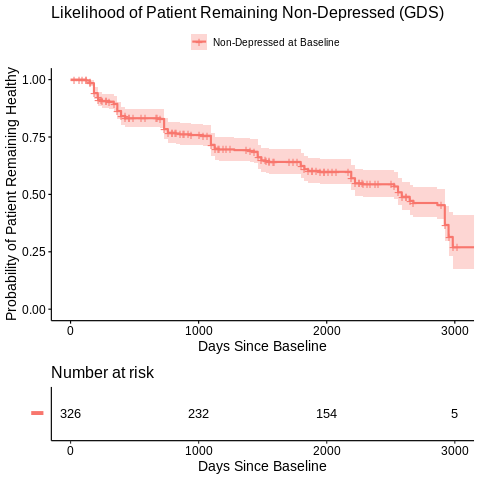

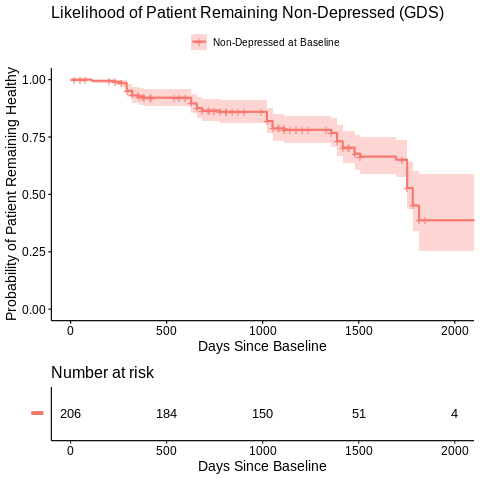

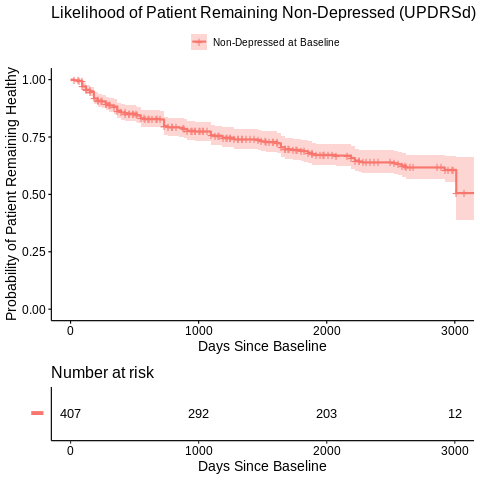

In [ ]:
%%R
TIFFY <- function(file_name){
    ggsave(file = file_name,plot = print(g),dpi=600,device="tiff",path = "/content/gdrive/My Drive/R/figures")
}

temp <- mutate(PPMI_coxdat, TSTART = TSTART * 365.25, TEND = TEND * 365.25)

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ 1, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    legend.title = "",
    legend.lab = "Non-Depressed at Baseline",
    risk.table.y.text = F,
    risk.table = TRUE)

print(g)

TIFFY("MainFig1A")

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ 1, data = filter(mutate(PPMI_coxdat, TEND = (TEND - 3.2) * 365, TSTART = (TSTART - 3.2) * 365), TEND > 0)),
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    legend.title = "",
    legend.lab = "Non-Depressed at Baseline",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    risk.table.y.text = F,
    risk.table = TRUE)
print(g)

temp <- mutate(PPMI_sddat, TSTART = 365 * TSTART, TEND = TEND * 365)

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, SD2) ~ PD_STATUS, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    legend.title = "",
    legend.lab = "Non-Depressed at Baseline",
    title = "Likelihood of Patient Remaining Non-Depressed (UPDRSd)", 
    risk.table.y.text = F,
    risk.table = TRUE)

print(g)

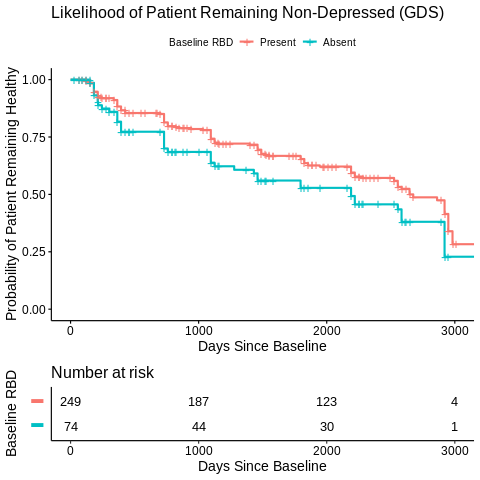

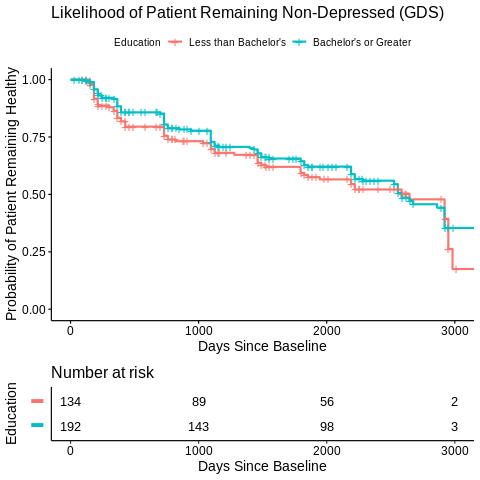

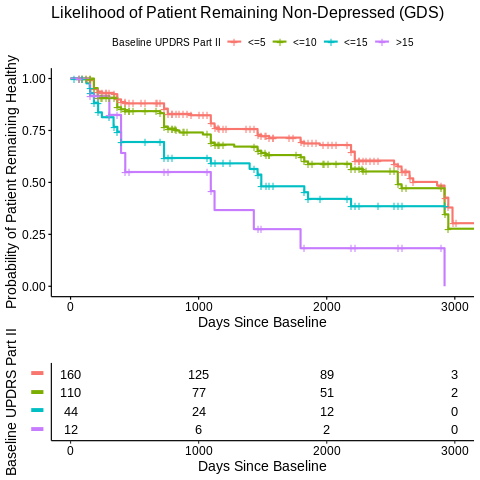

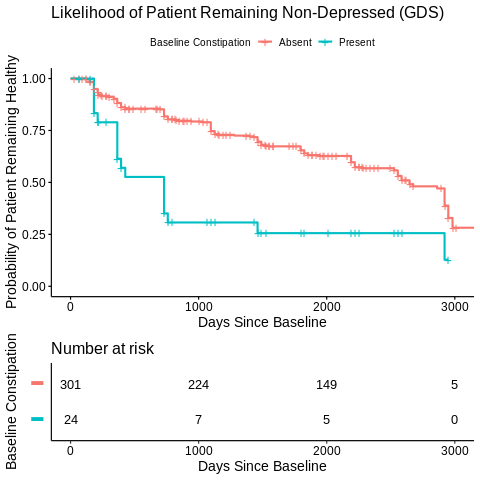

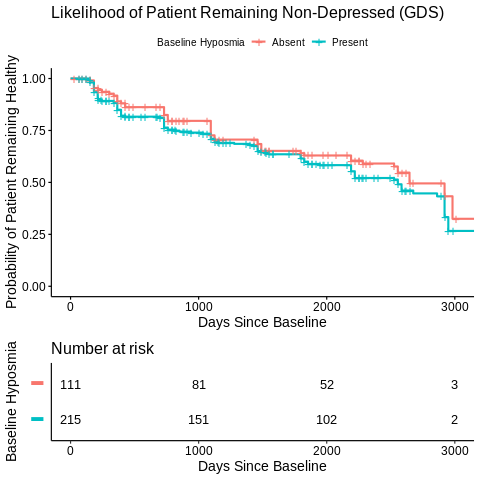

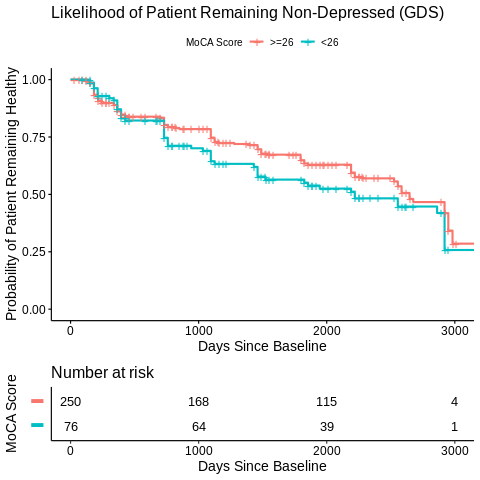

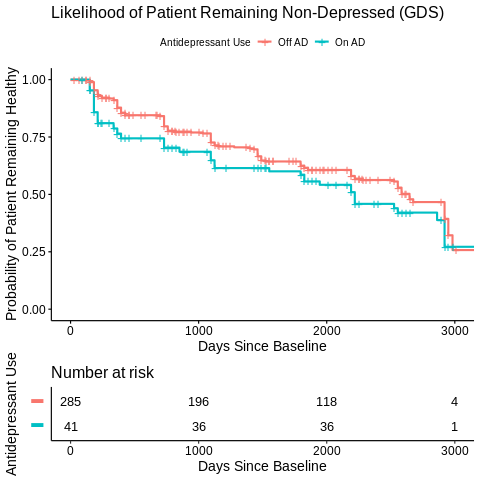

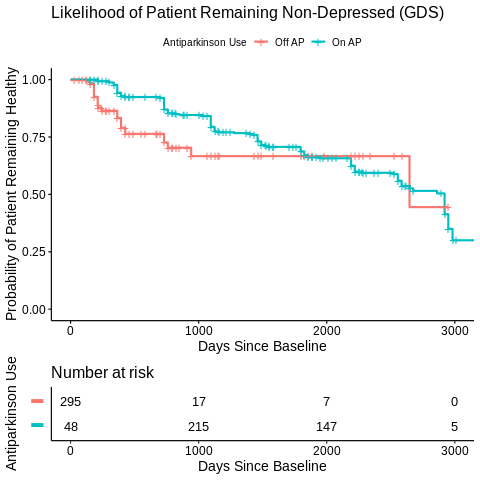

In [ ]:
%%R
temp <- mutate(PPMI_coxdat, TSTART = TSTART * 365, TEND = TEND * 365)

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ BL_RBD, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    legend.labs = c("Present","Absent"), 
    legend.title = "Baseline RBD",
    risk.table.y.text = F,
    risk.table = T)


print(g)

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ I(EDUCYRS > 15), data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    legend.title = "Education",
    legend.labs = c("Less than Bachelor's","Bachelor's or Greater"), 
    risk.table.y.text = F,
    risk.table = T)


print(g)

temp <- mutate(temp, UP2_bin = case_when(BL_UP2 <= 5  ~ 0,
                                 BL_UP2 <= 10 ~ 1,
                                 BL_UP2 <= 15 ~ 2,
                                 TRUE ~ 3))

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ UP2_bin, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    legend.title = "Baseline UPDRS Part II",
    legend.labs = c("<=5", "<=10", "<=15",">15"), 
    risk.table.y.text = F,
    risk.table.height = 0.3,
    risk.table.title = "",
    risk.table = T)


print(g)


temp <- mutate(temp, BL_CNST = if_else(BL_CNST == 0, 0, 1))

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ BL_CNST, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    legend.title = "Baseline Constipation",
    legend.labs = c("Absent", "Present"),
    risk.table.y.text = F,
    risk.table.height = 0.3,
    risk.table = T)


print(g)


temp <- mutate(temp, BL_CNST = if_else(BL_CNST == 0, 0, 1))

temp <- mutate(temp, BL_HALL = if_else(BL_HALL == 0, 0, 1))

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ BL_HYP, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    legend.title = "Baseline Hyposmia",
    legend.labs = c("Absent", "Present"),
    risk.table.y.text = F,
    risk.table.height = 0.3,
    risk.table = T)


print(g)



temp <- mutate(temp, mca_bin = case_when(MCATOT >= 26  ~ 0,
                                 TRUE ~ 1))



g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ mca_bin, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    legend.title = "MoCA Score",
    legend.labs = c(">=26", "<26"), 
    risk.table.y.text = F,
    risk.table = T)


print(g)



g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ DEP_MED, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    legend.labs = c("Off AD", "On AD"), 
    legend.title = c("Antidepressant Use"),
    risk.table.y.text = F,
    risk.table = T)


print(g)


temp <- mutate(temp, PD_MED_USE = if_else(PD_MED_USE == 0, 0, 1))


g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ PD_MED_USE, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (GDS)", 
    legend.labs = c("Off AP", "On AP"), 
    legend.title = c("Antiparkinson Use"),
    risk.table.y.text = F,
    risk.table = T)


print(g)




### PDBP

R[write to console]: Saving 6.67 x 6.67 in image



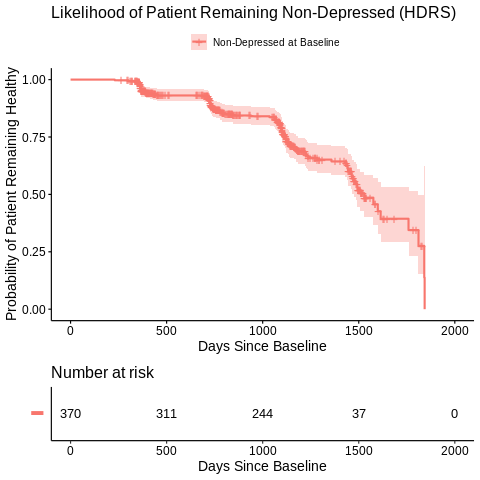

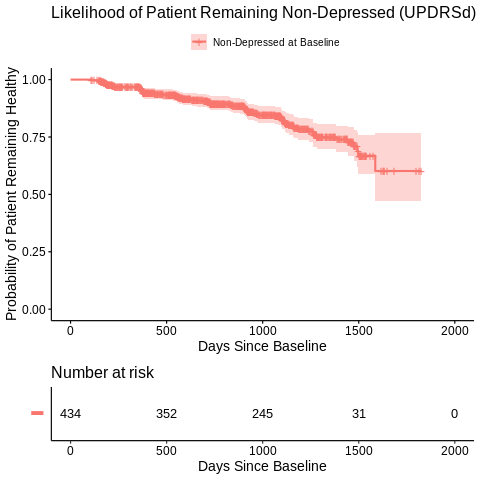

In [ ]:
%%R

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ 1, data = PDBP_coxdat), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (HDRS)", 
    legend.title = "",
    legend.lab = "Non-Depressed at Baseline",
    risk.table.y.text = F,
    risk.table = T)

print(g)

TIFFY("MainFig1B")


g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, SD2) ~ 1, data = sd_dat_PD), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (UPDRSd)",
    legend.lab = "Non-Depressed at Baseline",
    legend.title = "", 
    risk.table.y.text = F,
    risk.table = T)


print(g)



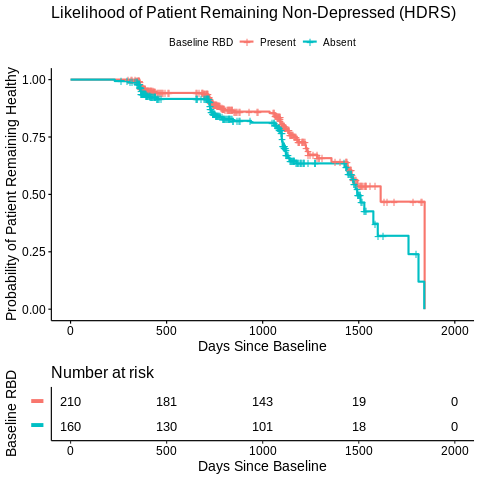

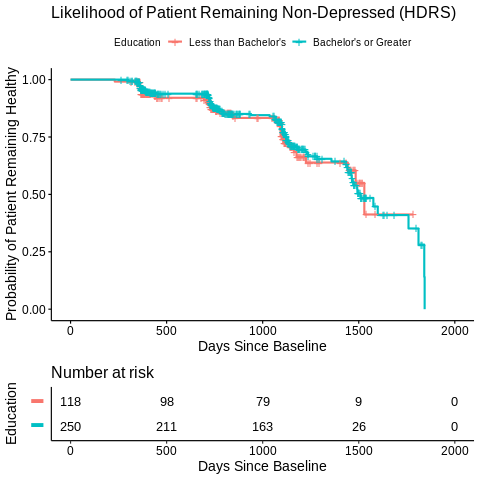

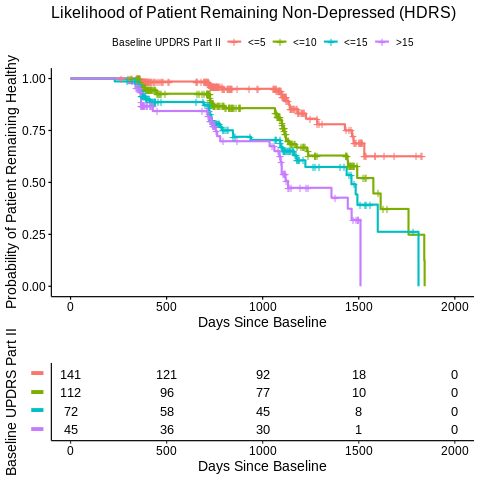

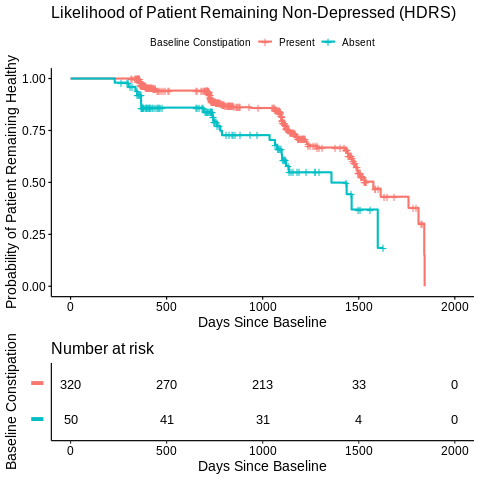

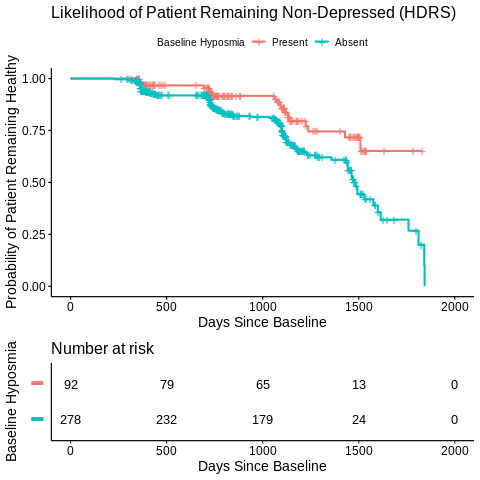

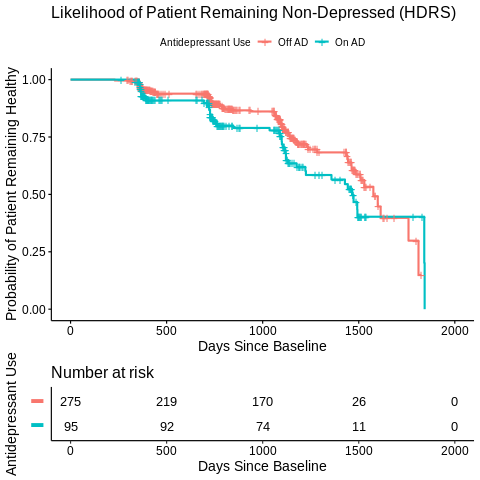

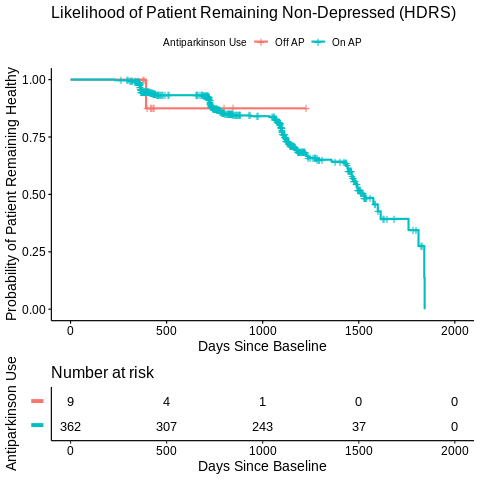

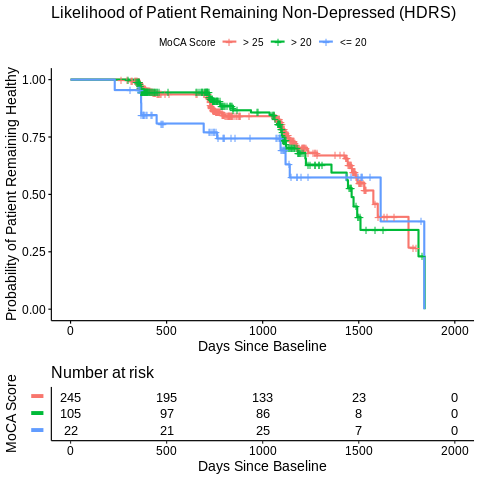

In [ ]:
%%R
g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ BL_RBD, data = PDBP_coxdat), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (HDRS)", 
    legend.labs = c("Present","Absent"), 
    legend.title = "Baseline RBD",
    risk.table.y.text = F,
    risk.table = T)

print(g)



g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ I(YEARSEDUC > 15), data = PDBP_coxdat), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (HDRS)", 
    legend.labs = c("Less than Bachelor's","Bachelor's or Greater"), 
    legend.title = "Education",
    risk.table.y.text = F,
    risk.table = T)

print(g)

temp <- mutate(PDBP_coxdat, UP2_bin = case_when(BL_UP2 <= 5  ~ 0,
                                 BL_UP2 <= 10 ~ 1,
                                 BL_UP2 <= 15 ~ 2,
                                 TRUE ~ 3))

g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ UP2_bin, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (HDRS)", 
    legend.title = "Baseline UPDRS Part II",
    legend.labs = c("<=5", "<=10", "<=15",">15"), 
    risk.table.y.text = F,
    risk.table.height = 0.3,
    risk.table.title = "",
    risk.table = T)


print(g)


g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ BL_CNST, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (HDRS)", 
    legend.title = "Baseline Constipation",
    legend.labs = c("Present","Absent"), 
    risk.table.y.text = F,
    risk.table.height = 0.3,
    risk.table = T)

print(g)



g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ BL_HYP, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (HDRS)", 
    legend.title = "Baseline Hyposmia",
    legend.labs = c("Present","Absent"), 
    risk.table.y.text = F,
    risk.table.height = 0.3,
    risk.table = T)

print(g)



g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ DEP_MED, data = PDBP_coxdat), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (HDRS)", 
    legend.labs = c("Off AD", "On AD"), 
    legend.title = c("Antidepressant Use"),
    risk.table.y.text = F,
    risk.table = T)

print(g)



g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ PD_MED_USE, data = PDBP_coxdat), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (HDRS)", 
    legend.labs = c("Off AP", "On AP"), 
    legend.title = c("Antiparkinson Use"),
    risk.table.y.text = F,
    risk.table = T)

print(g)


temp <- mutate(temp, mca_bin = case_when(MOCA_TOT > 25  ~ 1,
                                         MOCA_TOT > 20  ~ 2,
                                         TRUE  ~ 3))


g <- ggsurvplot(fit = survfit(Surv(TSTART, TEND, IS_DEP) ~ mca_bin, data = temp), 
    xlab = "Days Since Baseline", 
    ylab = "Probability of Patient Remaining Healthy",
    title = "Likelihood of Patient Remaining Non-Depressed (HDRS)", 
    legend.title = "MoCA Score",
    legend.labs = c("> 25","> 20","<= 20"),
    risk.table.y.text = F,
    risk.table = T)


print(g)



## Linear Mixed Effects

### PPMI

In [ ]:
%%R
library(dplyr, lib.loc = pack, quietly = TRUE)
library(lme4, lib.loc = pack, quietly = TRUE)
library(ggplot2, lib.loc = pack, quietly = TRUE)
library(ggeffects, lib.loc = pack, quietly = TRUE)
library(lmerTest, lib.loc = pack, quietly = TRUE)

PD_DA9 <- filter(GDSOC_DA9, PD_STATUS == 1)

ND_BL_PTs <- filter(PD_DA9, IS_DEP == 0 & EVENT_ID == "BL")$PATNO

PD_DA9 <- filter(PD_DA9, PATNO %in% ND_BL_PTs)

lmer.PD <- lmer(GDSTOT ~ TEND + (1|PATNO), data = PD_DA9)
lmer.PD2 <- lmer(SUBDEP ~ TEND + (1|PATNO), data = PD_DA9)

print(summary(lmer.PD))
print(confint(lmer.PD))
print(summary(lmer.PD2))
print(confint(lmer.PD2))

R[write to console]: Registered S3 methods overwritten by 'lme4':
  method                          from
  cooks.distance.influence.merMod car 
  influence.merMod                car 
  dfbeta.influence.merMod         car 
  dfbetas.influence.merMod        car 

R[write to console]: 
Attaching package: ‘lmerTest’


R[write to console]: The following object is masked from ‘package:lme4’:

    lmer


R[write to console]: The following object is masked from ‘package:stats’:

    step




Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: GDSTOT ~ TEND + (1 | PATNO)
   Data: PD_DA9

REML criterion at convergence: 8607.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.5596 -0.5165 -0.0482  0.3989  7.9549 

Random effects:
 Groups   Name        Variance Std.Dev.
 PATNO    (Intercept) 0.4823   0.6945  
 Residual             1.3920   1.1798  
Number of obs: 2580, groups:  PATNO, 326

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept) 4.903e+00  5.332e-02 6.112e+02  91.944   <2e-16 ***
TEND        8.630e-02  9.810e-03 2.385e+03   8.797   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
     (Intr)
TEND -0.525


R[write to console]: Computing profile confidence intervals ...



                 2.5 %    97.5 %
.sig01      0.62236449 0.7707836
.sigma      1.14600445 1.2148297
(Intercept) 4.79831856 5.0074294
TEND        0.06703735 0.1055254
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: SUBDEP ~ TEND + (1 | PATNO)
   Data: PD_DA9

REML criterion at convergence: 4462.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.8605 -0.4759 -0.1763  0.2173  5.2214 

Random effects:
 Groups   Name        Variance Std.Dev.
 PATNO    (Intercept) 0.1520   0.3899  
 Residual             0.2657   0.5155  
Number of obs: 2580, groups:  PATNO, 326

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept) 2.907e-01  2.697e-02 4.979e+02  10.779  < 2e-16 ***
TEND        2.595e-02  4.308e-03 2.346e+03   6.023 1.98e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
     (Intr)
TEND -0.452


R[write to console]: Computing profile confidence intervals ...



                 2.5 %     97.5 %
.sig01      0.35349455 0.42888975
.sigma      0.50068843 0.53083600
(Intercept) 0.23778503 0.34355725
TEND        0.01749349 0.03439045


### PDBP

In [ ]:
%%R
library(dplyr, lib.loc = pack, quietly = TRUE)
library(lme4, lib.loc = pack, quietly = TRUE)
library(ggplot2, lib.loc = pack, quietly = TRUE)
library(ggeffects, lib.loc = pack, quietly = TRUE)
library(lmerTest, lib.loc = pack, quietly = TRUE)

PD_dat <- filter(raw_dat_s, Dx == "PD")

ND_BL_PTs <- filter(PDBP_log, IS_DEP == 0)$SGUID

PD_dat <- filter(PD_dat, SGUID %in% ND_BL_PTs)

lmer.PD <- lmer(HAMTOT ~ YRS_BL + (1|SGUID), data = PD_dat)

lmer.PD2 <- lmer(SUB_DEP ~ YRS_BL + (1|SGUID), data = PD_dat)

print(summary(lmer.PD))
print(confint(lmer.PD))
print(summary(lmer.PD2))
print(confint(lmer.PD2))


Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: HAMTOT ~ YRS_BL + (1 | SGUID)
   Data: PD_dat

REML criterion at convergence: 7039.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.4470 -0.5861 -0.0981  0.4722  5.2105 

Random effects:
 Groups   Name        Variance Std.Dev.
 SGUID    (Intercept) 5.825    2.413   
 Residual             7.753    2.784   
Number of obs: 1341, groups:  SGUID, 388

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)    3.3992     0.1726  698.4310   19.69   <2e-16 ***
YRS_BL         0.6791     0.0633 1091.9976   10.73   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
       (Intr)
YRS_BL -0.531


R[write to console]: Computing profile confidence intervals ...



                2.5 %   97.5 %
.sig01      2.1742742 2.663507
.sigma      2.6629328 2.912320
(Intercept) 3.0608034 3.737707
YRS_BL      0.5549646 0.803198
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: SUB_DEP ~ YRS_BL + (1 | SGUID)
   Data: PD_dat

REML criterion at convergence: 4202.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.1054 -0.4364 -0.2174  0.0288  6.7332 

Random effects:
 Groups   Name        Variance Std.Dev.
 SGUID    (Intercept) 0.1291   0.3593  
 Residual             0.2725   0.5220  
Number of obs: 2391, groups:  SGUID, 388

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept) 1.825e-01  2.602e-02 8.116e+02   7.015 4.85e-12 ***
YRS_BL      6.760e-02  9.640e-03 2.224e+03   7.012 3.10e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
       (Intr)
YRS_BL -0.565


R[write to console]: Computing profile confidence intervals ...



                 2.5 %     97.5 %
.sig01      0.32595363 0.39468122
.sigma      0.50618996 0.53836617
(Intercept) 0.13154811 0.23358624
YRS_BL      0.04870592 0.08650577
